In [1]:
CONFIG = {
    # Paths - fixed Kaggle input, no root auto-detection
    'data_root' : '/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset',
    'train_dir' : '/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Training',
    'test_dir'  : '/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Testing',
    'image_dir' : '/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset',

    # Outputs
    'output_dir'     : '/kaggle/working/outputs',
    'checkpoint_dir' : '/kaggle/working/checkpoints',
    'results_dir'    : '/kaggle/working/results',
    'figures_dir'    : '/kaggle/working/figures',

    # Brain Tumor MRI Dataset classes
    'class_names' : ['glioma', 'meningioma', 'notumor', 'pituitary'],
    'num_classes' : 4,
    'val_size'    : 0.10,

    # Training
    'image_size'      : 224,
    'batch_size'      : 32,
    'num_epochs'      : 20,
    'retrain_epochs'  : 10,
    'lr'              : 1e-4,
    'retrain_lr'      : 5e-5,
    'weight_decay'    : 1e-4,
    'seed'            : 42,
    'num_workers'     : 4,
    'patience'        : 5,
    'retrain_patience': 5,
    'max_samples'     : None,
    'show_batch_progress': False,
    'prefetch_factor' : 2,

    # Failure analysis - fast clustering/profiling settings from the augmentation framework
    'pca_components'               : 32,
    'umap_neighbors'               : 15,
    'umap_min_dist'                : 0.1,
    'k_range'                      : range(2, 7),
    'small_failure_umap_threshold' : 300,
    'max_aug_source'               : 300,
    'ece_bins'                     : 15,
    'aug_multiplier'               : 3,

    # Degradation guard - absolute-drop based
    'guard_f1_max_drop': 0.000,         # Zero tolerance (strict policy)
    'guard_acc_max_drop': 0.005,
    'guard_ece_max_rise': 0.010,
    'guard_weak_baseline_f1': 0.55,
    'guard_weak_f1_max_drop': 0.005,
    'guard_weak_acc_max_drop': 0.010,
    'guard_weak_ece_max_rise': 0.025,
}

MODELS = [
    'resnet50',
    'resnet101',
    'densenet121',
    # 'efficientnet_b3',
    # 'efficientnet_b5',
    # 'mobilenetv3_large_100',
    # 'vit_base_patch16_224',
    # 'swin_tiny_patch4_window7_224',
    # 'convnext_small',
    # 'maxvit_tiny_tf_224',
]

print("? CONFIG loaded - Brain Tumor MRI | train/test folders | val split from training")
print(f"  Classes    : {CONFIG['class_names']}")
print(f"  Training   : {CONFIG['num_epochs']} epochs | lr={CONFIG['lr']} | patience={CONFIG['patience']}")
print(f"  Retraining : {CONFIG['retrain_epochs']} epochs | lr={CONFIG['retrain_lr']} | patience={CONFIG['retrain_patience']}")
print(f"  Models     : {len(MODELS)} total")


? CONFIG loaded - Brain Tumor MRI | train/test folders | val split from training
  Classes    : ['glioma', 'meningioma', 'notumor', 'pituitary']
  Training   : 20 epochs | lr=0.0001 | patience=5
  Retraining : 10 epochs | lr=5e-05 | patience=5
  Models     : 3 total


In [2]:
!pip install -q timm umap-learn torchmetrics

import os, random, warnings, gc, json, math
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch.cuda.amp import GradScaler, autocast
import torchvision.transforms as T
from torchvision import models
from PIL import Image

import timm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score, confusion_matrix, precision_recall_fscore_support
)
import umap
import torchmetrics

try:
    from scipy import ndimage
except Exception:
    ndimage = None

try:
    from skimage.filters import threshold_otsu
except Exception:
    threshold_otsu = None

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")

def set_all_seeds(seed: int) -> None:
    """Set Python, NumPy, and PyTorch seeds for reproducible Kaggle runs."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = True

set_all_seeds(CONFIG['seed'])

for key in ['output_dir', 'checkpoint_dir', 'results_dir', 'figures_dir']:
    Path(CONFIG[key]).mkdir(parents=True, exist_ok=True)

assert torch.cuda.is_available(), "GPU is required for this Kaggle experiment."
device = torch.device("cuda")
print(f"Using device: {device} | GPU: {torch.cuda.get_device_name(0)}")
print("✓ Section 1 complete")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 108.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cudf-cu12 26.2.1 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incom

2026-06-15 08:29:00.408333: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1781512140.625474      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1781512140.685313      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1781512141.166361      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781512141.166401      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781512141.166404      23 computation_placer.cc:177] computation placer alr

Using device: cuda | GPU: Tesla T4
✓ Section 1 complete


In [3]:
print("Torch:", torch.__version__)
print("CUDA build:", torch.version.cuda)
print("CUDA available:", torch.cuda.is_available())

gpu_name = torch.cuda.get_device_name(0)
gpu_capability = torch.cuda.get_device_capability(0)

print("GPU:", gpu_name)
print("Capability:", gpu_capability)

if gpu_capability[0] < 7:
    raise RuntimeError(
        f"{gpu_name} capability={gpu_capability} is too old for this Kaggle PyTorch CUDA build. "
        "Switch Kaggle GPU to T4/L4/A100, restart runtime, then run again."
    )

device = torch.device("cuda")


Torch: 2.10.0+cu128
CUDA build: 12.8
CUDA available: True
GPU: Tesla T4
Capability: (7, 5)


In [4]:
print("Torch:", torch.__version__)
print("CUDA build:", torch.version.cuda)
print("CUDA available:", torch.cuda.is_available())

gpu_name = torch.cuda.get_device_name(0)
gpu_capability = torch.cuda.get_device_capability(0)

print("GPU:", gpu_name)
print("Capability:", gpu_capability)

if gpu_capability[0] < 7:
    raise RuntimeError(
        f"{gpu_name} capability={gpu_capability} is too old for this Kaggle PyTorch CUDA build. "
        "Switch Kaggle GPU to T4/L4/A100, restart runtime, then run again."
    )

device = torch.device("cuda")


Torch: 2.10.0+cu128
CUDA build: 12.8
CUDA available: True
GPU: Tesla T4
Capability: (7, 5)


Using Brain MRI root : /kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset
Using training folder: /kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Training
Using testing folder : /kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Testing

Original folders -> Training:5,600 | Testing:1,600
Splits -> Train:5,040 | Val:560 | Test:1,600

Train distribution
label_name
glioma        1260
meningioma    1260
notumor       1260
pituitary     1260
Name: count, dtype: int64

Val distribution
label_name
glioma        140
meningioma    140
notumor       140
pituitary     140
Name: count, dtype: int64

Test distribution
label_name
glioma        400
meningioma    400
notumor       400
pituitary     400
Name: count, dtype: int64

Splits saved to /kaggle/working


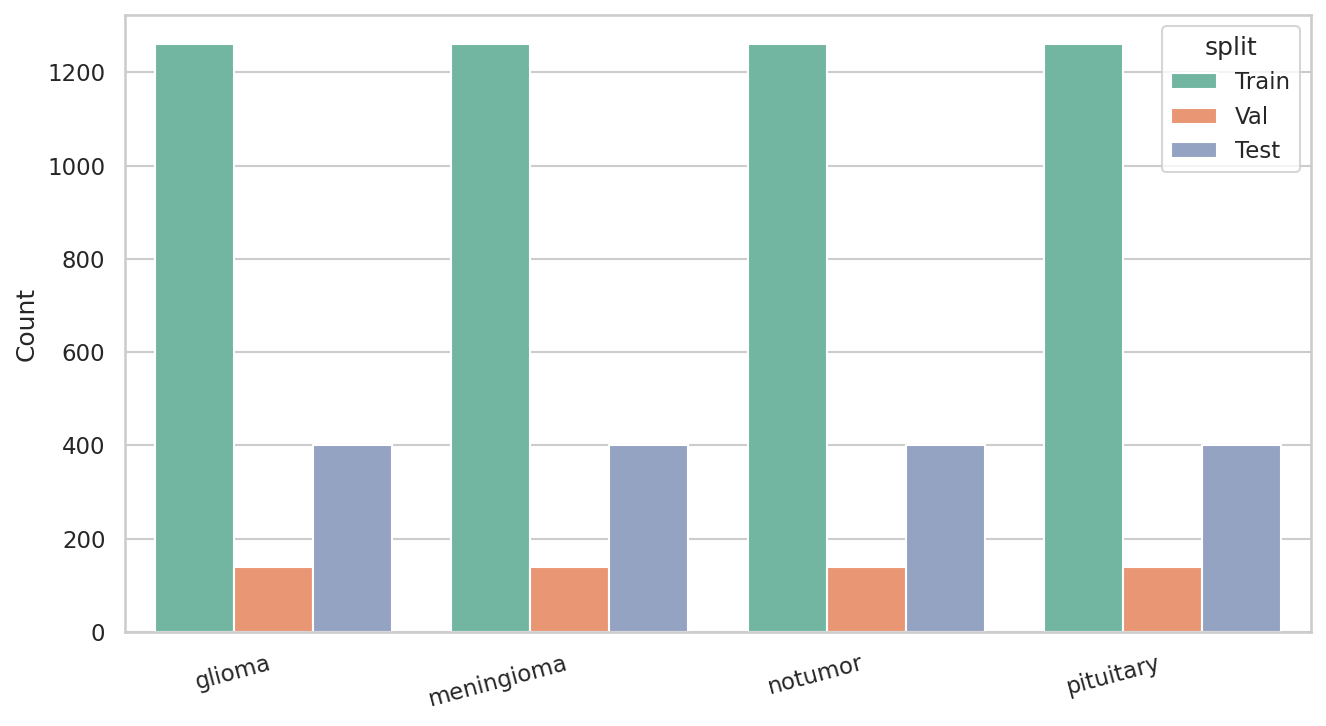

? Section 2 complete


In [5]:
def list_brain_mri_images(split_dir: Path, class_name: str) -> pd.DataFrame:
    """List image files for one Brain Tumor MRI class folder."""
    class_dir = split_dir / class_name
    if not class_dir.exists():
        raise FileNotFoundError(f"Missing class folder for {class_name}: {class_dir}")

    exts = {'.png', '.jpg', '.jpeg', '.bmp', '.tif', '.tiff'}
    paths = sorted(p for p in class_dir.iterdir() if p.is_file() and p.suffix.lower() in exts)
    if len(paths) == 0:
        raise FileNotFoundError(f"No image files found for {class_name}: {class_dir}")

    return pd.DataFrame({
        'image': [p.stem for p in paths],
        'image_path': [str(p) for p in paths],
        'label_name': class_name,
        'original_labels': class_name,
    })


def load_brain_mri_split(split_dir: Path, config: dict) -> pd.DataFrame:
    """Load one Brain Tumor MRI folder split."""
    if not split_dir.exists():
        raise FileNotFoundError(f"Missing split folder: {split_dir}")

    df = pd.concat(
        [list_brain_mri_images(split_dir, class_name) for class_name in config['class_names']],
        ignore_index=True
    )

    label_to_idx = {name: idx for idx, name in enumerate(config['class_names'])}
    df['label'] = df['label_name'].map(label_to_idx).astype(int)
    return df[['image', 'image_path', 'label', 'label_name', 'original_labels']].reset_index(drop=True)


def preprocess_labels(config: dict):
    """Load Brain Tumor MRI Training/Testing folders, split validation from Training, and save CSVs."""
    root = Path(config['data_root'])
    train_dir = Path(config['train_dir'])
    test_dir = Path(config['test_dir'])

    required_paths = {
        'data_root': root,
        'train_dir': train_dir,
        'test_dir': test_dir,
    }
    missing_paths = [f"{name}: {path}" for name, path in required_paths.items() if not path.exists()]
    if missing_paths:
        raise FileNotFoundError(
            "Some fixed CONFIG paths do not exist. Edit Cell 1 paths:\n" + "\n".join(missing_paths)
        )

    config['image_dir'] = str(root)
    print(f"Using Brain MRI root : {root}")
    print(f"Using training folder: {train_dir}")
    print(f"Using testing folder : {test_dir}")

    train_full_df = load_brain_mri_split(train_dir, config)
    test_df = load_brain_mri_split(test_dir, config)

    train_df, val_df = train_test_split(
        train_full_df,
        test_size=config.get('val_size', 0.15),
        random_state=config['seed'],
        stratify=train_full_df['label']
    )

    train_df = train_df.reset_index(drop=True)
    val_df = val_df.reset_index(drop=True)
    test_df = test_df.reset_index(drop=True)

    print(f"\nOriginal folders -> Training:{len(train_full_df):,} | Testing:{len(test_df):,}")
    print(f"Splits -> Train:{len(train_df):,} | Val:{len(val_df):,} | Test:{len(test_df):,}")
    for split_name, split_df in [('Train', train_df), ('Val', val_df), ('Test', test_df)]:
        print(f"\n{split_name} distribution")
        print(split_df['label_name'].value_counts().reindex(config['class_names']).fillna(0).astype(int))

    train_df.to_csv('/kaggle/working/train_split.csv', index=False)
    val_df.to_csv('/kaggle/working/val_split.csv', index=False)
    test_df.to_csv('/kaggle/working/test_split.csv', index=False)
    print("\nSplits saved to /kaggle/working")

    dist = pd.concat([
        train_df.assign(split='Train'),
        val_df.assign(split='Val'),
        test_df.assign(split='Test'),
    ])

    plt.figure(figsize=(9, 5), dpi=150)
    ax = sns.countplot(
        data=dist,
        x='label_name',
        hue='split',
        order=config['class_names'],
        palette='Set2'
    )
    ax.set_xlabel("")
    ax.set_ylabel("Count")
    plt.xticks(rotation=15, ha='right')
    plt.tight_layout()
    plt.savefig(f"{config['figures_dir']}/section2_class_distribution.png", dpi=300, bbox_inches='tight')
    plt.show()

    return train_df, val_df, test_df


train_df, val_df, test_df = preprocess_labels(CONFIG)
print("? Section 2 complete")


In [6]:
class BrainMRIDataset(Dataset):
    """Brain Tumor MRI dataset that loads images as RGB tensors for ImageNet-pretrained backbones."""
    missing_warning_count = 0

    def __init__(self, df: pd.DataFrame, transform=None, image_dir=None):
        self.df = df.reset_index(drop=True).copy()
        self.transform = transform
        self.image_dir = image_dir

    def __len__(self):
        """Return number of samples."""
        return len(self.df)

    def __getitem__(self, idx):
        """Load image, apply transforms, and return tensor, label, and path."""
        row = self.df.iloc[idx]
        image_path = row['image_path']
        try:
            image = Image.open(image_path).convert('RGB')
        except FileNotFoundError:
            BrainMRIDataset.missing_warning_count += 1
            if BrainMRIDataset.missing_warning_count <= 10:
                print(f"Warning: missing image skipped via blank placeholder: {image_path}")
            image = Image.fromarray(np.zeros((CONFIG['image_size'], CONFIG['image_size'], 3), dtype=np.uint8))
        except Exception as exc:
            BrainMRIDataset.missing_warning_count += 1
            if BrainMRIDataset.missing_warning_count <= 10:
                print(f"Warning: failed to load {image_path}: {exc}; using blank placeholder")
            image = Image.fromarray(np.zeros((CONFIG['image_size'], CONFIG['image_size'], 3), dtype=np.uint8))
        if self.transform:
            image = self.transform(image)
        return image, int(row['label']), image_path


def get_transforms(split: str, image_size: int):
    """Build train/validation/test transforms for 224 RGB model inputs."""
    mean = [0.485, 0.456, 0.406]
    std = [0.229, 0.224, 0.225]
    if split == 'train':
        return T.Compose([
            T.RandomHorizontalFlip(0.5),
            T.RandomRotation(10),
            T.ColorJitter(brightness=0.15, contrast=0.15),
            T.RandomAffine(degrees=0, translate=(0.05, 0.05)),
            T.Resize(image_size + 32),
            T.RandomCrop(image_size),
            T.ToTensor(),
            T.Normalize(mean, std),
        ])
    if split == 'heavy':
        return T.Compose([
            T.RandomHorizontalFlip(0.5),
            T.RandomRotation(25),
            T.ColorJitter(brightness=0.25, contrast=0.25),
            T.RandomAffine(degrees=15, translate=(0.1, 0.1), scale=(0.9, 1.1)),
            T.GaussianBlur(kernel_size=5, sigma=(0.1, 2.0)),
            T.Resize(image_size + 32),
            T.RandomCrop(image_size),
            T.ToTensor(),
            T.Normalize(mean, std),
        ])
    return T.Compose([
        T.Resize(image_size),
        T.CenterCrop(image_size),
        T.ToTensor(),
        T.Normalize(mean, std),
    ])


class AugmentedBrainMRIDataset(BrainMRIDataset):
    """Dataset that applies heavy transforms to rows marked as augmented copies."""
    def __init__(self, df, normal_transform, heavy_transform):
        super().__init__(df, normal_transform)
        self.normal_transform = normal_transform
        self.heavy_transform = heavy_transform

    def __getitem__(self, idx):
        """Load image and choose normal or heavy transform based on is_augmented."""
        row = self.df.iloc[idx]
        transform = self.heavy_transform if bool(row.get('is_augmented', False)) else self.normal_transform
        old_transform = self.transform
        self.transform = transform
        item = super().__getitem__(idx)
        self.transform = old_transform
        return item


def compute_class_weights(df: pd.DataFrame, num_classes: int) -> torch.Tensor:
    """Compute inverse-frequency class weights for weighted cross entropy."""
    counts = df['label'].value_counts().reindex(range(num_classes)).fillna(1).astype(float).values
    total = counts.sum()
    weights = total / (num_classes * counts)
    return torch.tensor(weights, dtype=torch.float32)


def get_dataloaders(train_df: pd.DataFrame, test_df: pd.DataFrame, config: dict, val_df: pd.DataFrame = None):
    """Create train, validation, and test loaders with weighted sampling for training."""
    if val_df is None:
        train_split, val_split = train_test_split(
            train_df, test_size=0.2, random_state=config['seed'], stratify=train_df['label']
        )
    else:
        train_split = train_df.copy()
        val_split = val_df.copy()

    train_transform = get_transforms('train', config['image_size'])
    heavy_transform = get_transforms('heavy', config['image_size'])
    eval_transform = get_transforms('test', config['image_size'])

    if 'is_augmented' in train_split.columns:
        train_ds = AugmentedBrainMRIDataset(train_split, train_transform, heavy_transform)
    else:
        train_ds = BrainMRIDataset(train_split, train_transform, config['image_dir'])
    val_ds = BrainMRIDataset(val_split, eval_transform, config['image_dir'])
    test_ds = BrainMRIDataset(test_df, eval_transform, config['image_dir'])

    class_weights = compute_class_weights(train_split, config['num_classes'])
    if 'sample_weight' in train_split.columns:
        sample_weights = train_split['sample_weight'].astype(float).values
    else:
        sample_weights = train_split['label'].map({i: class_weights[i].item() for i in range(config['num_classes'])}).values

    sampler = WeightedRandomSampler(
        weights=torch.tensor(sample_weights, dtype=torch.double),
        num_samples=len(sample_weights),
        replacement=True
    )

    loader_kwargs = dict(
        batch_size=config['batch_size'],
        num_workers=config['num_workers'],
        pin_memory=True,
    )
    if config['num_workers'] > 0:
        loader_kwargs.update(
            persistent_workers=True,
            prefetch_factor=config.get('prefetch_factor', 2),
        )

    train_loader = DataLoader(train_ds, sampler=sampler, **loader_kwargs)
    val_loader = DataLoader(val_ds, shuffle=False, **loader_kwargs)
    test_loader = DataLoader(test_ds, shuffle=False, **loader_kwargs)
    return train_loader, val_loader, test_loader, class_weights


train_loader, val_loader, test_loader, class_weights = get_dataloaders(train_df, test_df, CONFIG, val_df=val_df)
print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)} | Test batches: {len(test_loader)}")
print(f"Class weights: {class_weights.tolist()}")
print("? Section 3 complete")


Train batches: 158 | Val batches: 18 | Test batches: 50
Class weights: [1.0, 1.0, 1.0, 1.0]
? Section 3 complete


In [7]:
def get_model(model_name: str, num_classes: int, pretrained: bool = True):
    """Instantiate a torchvision or timm classifier and move it to GPU."""
    if model_name == 'resnet50':
        model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT if pretrained else None)
        model.fc = nn.Linear(model.fc.in_features, num_classes)
    elif model_name == 'resnet101':
        model = models.resnet101(weights=models.ResNet101_Weights.DEFAULT if pretrained else None)
        model.fc = nn.Linear(model.fc.in_features, num_classes)
    elif model_name == 'densenet121':
        model = models.densenet121(weights=models.DenseNet121_Weights.DEFAULT if pretrained else None)
        model.classifier = nn.Linear(model.classifier.in_features, num_classes)
    elif model_name == 'mobilenetv3_large_100':
        model = models.mobilenet_v3_large(weights=models.MobileNet_V3_Large_Weights.DEFAULT if pretrained else None)
        model.classifier[-1] = nn.Linear(model.classifier[-1].in_features, num_classes)
    else:
        model = timm.create_model(model_name, pretrained=pretrained, num_classes=num_classes)
    model = model.to(device)
    params = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"{model_name}: {params/1e6:.2f}M params ({trainable/1e6:.2f}M trainable)")
    return model


def get_embedding_hook(model: nn.Module, model_name: str):
    """Register a forward hook on the best available penultimate representation layer."""
    embedding_store = {}

    def hook_fn(module, inputs, output):
        out = output
        if isinstance(out, (tuple, list)):
            out = out[0]
        if out.ndim == 4:
            out = torch.nn.functional.adaptive_avg_pool2d(out, 1).flatten(1)
        elif out.ndim == 3:
            out = out[:, 0] if out.shape[1] > 1 else out.mean(dim=1)
        else:
            out = out.flatten(1)
        embedding_store['embedding'] = out.detach().cpu()

    target = None
    if model_name.startswith('resnet'):
        target = model.avgpool
    elif model_name.startswith('densenet'):
        target = model.features
    elif model_name.startswith('efficientnet') and hasattr(model, 'global_pool'):
        target = model.global_pool
    elif model_name.startswith('mobilenetv3') and hasattr(model, 'avgpool'):
        target = model.avgpool
    elif model_name.startswith('vit') and hasattr(model, 'norm'):
        target = model.norm
    elif model_name.startswith('swin') and hasattr(model, 'norm'):
        target = model.norm
    elif model_name.startswith('convnext'):
        target = getattr(model, 'norm_pre', None) or getattr(getattr(model, 'head', None), 'global_pool', None)
    elif model_name.startswith('maxvit') and hasattr(model, 'norm'):
        target = model.norm

    if target is None:
        if hasattr(model, 'forward_features'):
            raise ValueError(f"No hook target found for {model_name}; add architecture-specific hook.")
        raise ValueError(f"No embedding layer available for {model_name}.")

    handle = target.register_forward_hook(hook_fn)
    return handle, embedding_store


def get_model_family(model_name: str) -> str:
    """Map model name to retraining strategy family."""
    if model_name.startswith('efficientnet'):
        return 'efficient'
    if model_name.startswith(('vit', 'swin', 'convnext', 'maxvit')):
        return 'transformer'
    return 'cnn'

print("✓ Section 4 complete")


✓ Section 4 complete


In [8]:
def train_one_epoch(model, loader, optimizer, criterion, scaler, device):
    """Train one epoch with CUDA mixed precision and return loss and accuracy."""
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for images, labels, _ in tqdm(loader, desc='train', leave=False, disable=not CONFIG.get('show_batch_progress', False)):
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        with autocast():
            logits = model(images)
            loss = criterion(logits, labels)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        total_loss += loss.item() * labels.size(0)
        correct += (logits.argmax(1) == labels).sum().item()
        total += labels.size(0)
    return total_loss / max(total, 1), correct / max(total, 1)


def evaluate(model, loader, criterion, device, num_classes, class_names):
    """Evaluate loss, accuracy, macro F1, macro AUROC, ECE, predictions, and probabilities."""
    model.eval()
    f1_metric = torchmetrics.classification.F1Score(task='multiclass', num_classes=num_classes, average='macro').to(device)
    auc_metric = torchmetrics.classification.AUROC(task='multiclass', num_classes=num_classes, average='macro').to(device)
    total_loss, correct, total = 0.0, 0, 0
    probs_all, labels_all, preds_all, paths_all = [], [], [], []
    with torch.no_grad():
        for images, labels, paths in tqdm(loader, desc='eval', leave=False, disable=not CONFIG.get('show_batch_progress', False)):
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            logits = model(images)
            loss = criterion(logits, labels)
            probs = torch.softmax(logits, dim=1)
            preds = probs.argmax(1)
            total_loss += loss.item() * labels.size(0)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
            f1_metric.update(preds, labels)
            auc_metric.update(probs, labels)
            probs_all.append(probs.detach().cpu().numpy())
            labels_all.append(labels.detach().cpu().numpy())
            preds_all.append(preds.detach().cpu().numpy())
            paths_all.extend(list(paths))
    probs_array = np.concatenate(probs_all) if probs_all else np.empty((0, num_classes))
    labels_array = np.concatenate(labels_all) if labels_all else np.array([])
    preds_array = np.concatenate(preds_all) if preds_all else np.array([])
    try:
        auc = float(auc_metric.compute().detach().cpu())
    except Exception:
        auc = np.nan
    ece = compute_ece(probs_array, labels_array, CONFIG['ece_bins']) if len(labels_array) else np.nan
    return {
        'loss': total_loss / max(total, 1),
        'accuracy': correct / max(total, 1),
        'f1': float(f1_metric.compute().detach().cpu()),
        'auc': auc,
        'ece': ece,
        'probs': probs_array,
        'labels': labels_array,
        'preds': preds_array,
        'paths': paths_all,
    }


def compute_ece(probs_array, labels_array, n_bins=15):
    """Compute expected calibration error from probability vectors and labels."""
    probs_array = np.asarray(probs_array)
    labels_array = np.asarray(labels_array)
    if len(labels_array) == 0:
        return np.nan
    confidences = probs_array.max(axis=1)
    predictions = probs_array.argmax(axis=1)
    accuracies = (predictions == labels_array).astype(float)
    bins = np.linspace(0.0, 1.0, n_bins + 1)
    ece = 0.0
    for lo, hi in zip(bins[:-1], bins[1:]):
        mask = (confidences > lo) & (confidences <= hi)
        if mask.any():
            ece += mask.mean() * abs(accuracies[mask].mean() - confidences[mask].mean())
    return float(ece)




def temperature_scale(model, val_loader, device, num_classes):
    """Learn optimal temperature on val set; return temperature and scaled ECE."""
    temperature = torch.nn.Parameter(torch.ones(1) * 1.5)
    optimizer = torch.optim.LBFGS([temperature], lr=0.01, max_iter=50)

    logits_list, labels_list = [], []
    model.eval()
    with torch.no_grad():
        for images, labels, _ in val_loader:
            images = images.to(device, non_blocking=True)
            logits_list.append(model(images).detach().cpu())
            labels_list.append(labels.detach().cpu())

    all_logits = torch.cat(logits_list)
    all_labels = torch.cat(labels_list)
    criterion = torch.nn.CrossEntropyLoss()

    def eval_fn():
        optimizer.zero_grad()
        loss = criterion(all_logits / temperature.clamp_min(1e-3), all_labels)
        loss.backward()
        return loss

    optimizer.step(eval_fn)
    T = max(float(temperature.item()), 1e-3)

    scaled_probs = torch.softmax(all_logits / T, dim=1).numpy()
    ece_scaled = compute_ece(scaled_probs, all_labels.numpy(), CONFIG['ece_bins'])
    return T, ece_scaled


def plot_confusion_matrix(cm, class_names, model_name, save=True, suffix='baseline'):
    """Plot and optionally save a normalized confusion matrix."""
    row_sums = cm.sum(axis=1, keepdims=True)
    cm_norm = np.divide(cm, row_sums, out=np.zeros_like(cm, dtype=float), where=row_sums != 0)
    plt.figure(figsize=(6, 5), dpi=150)
    sns.heatmap(cm_norm, annot=True, fmt='.1%', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    if save:
        plt.savefig(f"{CONFIG['figures_dir']}/confusion_{suffix}_{model_name}.png", dpi=300, bbox_inches='tight')
    plt.show()


def train_model(model_name, train_loader, val_loader, class_weights, config):
    """Train a baseline model with early stopping on validation macro F1."""
    model = get_model(model_name, config['num_classes'], pretrained=True)
    criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))
    optimizer = torch.optim.AdamW(model.parameters(), lr=config['lr'], weight_decay=config['weight_decay'])
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=config['num_epochs'])
    scaler = GradScaler()
    history = defaultdict(list)
    best_f1, patience_counter = -np.inf, 0
    best_val_metrics = None
    ckpt_path = Path(config['checkpoint_dir']) / f"best_brainmri_{model_name}.pth"

    for epoch in range(1, config['num_epochs'] + 1):
        print(f"Epoch {epoch}/{config['num_epochs']} - {model_name}")
        train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, scaler, device)
        val_metrics = evaluate(model, val_loader, criterion, device, config['num_classes'], config['class_names'])
        scheduler.step()
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_metrics['loss'])
        history['val_acc'].append(val_metrics['accuracy'])
        history['val_f1'].append(val_metrics['f1'])
        history['val_auc'].append(val_metrics['auc'])
        print(f"loss {train_loss:.4f}/{val_metrics['loss']:.4f} | acc {train_acc:.3f}/{val_metrics['accuracy']:.3f} | val_f1 {val_metrics['f1']:.4f}")
        if val_metrics['f1'] > best_f1:
            best_f1 = val_metrics['f1']
            best_val_metrics = {
                'val_loss': val_metrics['loss'],
                'val_acc': val_metrics['accuracy'],
                'val_f1': val_metrics['f1'],
                'val_auc': val_metrics['auc'],
                'val_ece': val_metrics['ece'],
            }
            patience_counter = 0
            torch.save(model.state_dict(), ckpt_path)
            print(f"Saved best checkpoint: {ckpt_path}")
        else:
            patience_counter += 1
            if patience_counter >= config['patience']:
                print(f"Early stopping at epoch {epoch}. Best val F1={best_f1:.4f}")
                break

    model.load_state_dict(torch.load(ckpt_path, map_location=device))
    return model, dict(history), best_val_metrics

print("✓ Section 5 complete")


✓ Section 5 complete


Training models:   0%|          | 0/3 [00:00<?, ?it/s]


Training: resnet50
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth



  0%|          | 0.00/97.8M [00:00<?, ?B/s]
 15%|█▌        | 15.1M/97.8M [00:00<00:00, 159MB/s]
 35%|███▍      | 34.1M/97.8M [00:00<00:00, 182MB/s]
 59%|█████▉    | 57.5M/97.8M [00:00<00:00, 211MB/s]
100%|██████████| 97.8M/97.8M [00:00<00:00, 206MB/s]


resnet50: 23.52M params (23.52M trainable)
Epoch 1/20 - resnet50
loss 0.3855/0.1109 | acc 0.879/0.966 | val_f1 0.9658
Saved best checkpoint: /kaggle/working/checkpoints/best_brainmri_resnet50.pth
Epoch 2/20 - resnet50
loss 0.1058/0.1150 | acc 0.966/0.961 | val_f1 0.9607
Epoch 3/20 - resnet50
loss 0.0652/0.1486 | acc 0.979/0.952 | val_f1 0.9515
Epoch 4/20 - resnet50
loss 0.0403/0.0642 | acc 0.987/0.982 | val_f1 0.9821
Saved best checkpoint: /kaggle/working/checkpoints/best_brainmri_resnet50.pth
Epoch 5/20 - resnet50
loss 0.0377/0.0555 | acc 0.988/0.984 | val_f1 0.9839
Saved best checkpoint: /kaggle/working/checkpoints/best_brainmri_resnet50.pth
Epoch 6/20 - resnet50
loss 0.0269/0.0505 | acc 0.992/0.982 | val_f1 0.9821
Epoch 7/20 - resnet50
loss 0.0210/0.0594 | acc 0.994/0.977 | val_f1 0.9767
Epoch 8/20 - resnet50
loss 0.0179/0.0410 | acc 0.994/0.989 | val_f1 0.9893
Saved best checkpoint: /kaggle/working/checkpoints/best_brainmri_resnet50.pth
Epoch 9/20 - resnet50
loss 0.0131/0.0368 | ac

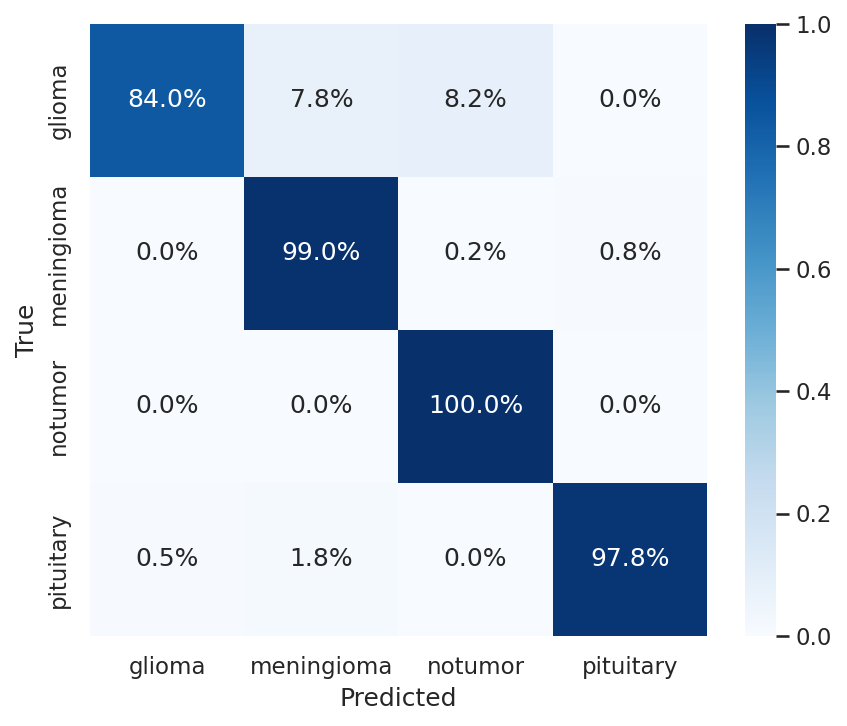


Training: resnet101
Downloading: "https://download.pytorch.org/models/resnet101-cd907fc2.pth" to /root/.cache/torch/hub/checkpoints/resnet101-cd907fc2.pth



  0%|          | 0.00/171M [00:00<?, ?B/s]
 10%|▉         | 17.0M/171M [00:00<00:00, 178MB/s]
 24%|██▎       | 40.4M/171M [00:00<00:00, 217MB/s]
 38%|███▊      | 64.0M/171M [00:00<00:00, 231MB/s]
 51%|█████▏    | 87.5M/171M [00:00<00:00, 236MB/s]
 65%|██████▌   | 111M/171M [00:00<00:00, 240MB/s] 
 79%|███████▊  | 134M/171M [00:00<00:00, 241MB/s]
100%|██████████| 171M/171M [00:00<00:00, 236MB/s]


resnet101: 42.51M params (42.51M trainable)
Epoch 1/20 - resnet101
loss 0.3951/0.1502 | acc 0.862/0.946 | val_f1 0.9462
Saved best checkpoint: /kaggle/working/checkpoints/best_brainmri_resnet101.pth
Epoch 2/20 - resnet101
loss 0.1032/0.1793 | acc 0.965/0.943 | val_f1 0.9427
Epoch 3/20 - resnet101
loss 0.0662/0.1012 | acc 0.980/0.970 | val_f1 0.9696
Saved best checkpoint: /kaggle/working/checkpoints/best_brainmri_resnet101.pth
Epoch 4/20 - resnet101
loss 0.0491/0.0606 | acc 0.983/0.971 | val_f1 0.9713
Saved best checkpoint: /kaggle/working/checkpoints/best_brainmri_resnet101.pth
Epoch 5/20 - resnet101
loss 0.0293/0.0517 | acc 0.991/0.980 | val_f1 0.9804
Saved best checkpoint: /kaggle/working/checkpoints/best_brainmri_resnet101.pth
Epoch 6/20 - resnet101
loss 0.0177/0.0539 | acc 0.995/0.982 | val_f1 0.9822
Saved best checkpoint: /kaggle/working/checkpoints/best_brainmri_resnet101.pth
Epoch 7/20 - resnet101
loss 0.0173/0.0679 | acc 0.994/0.986 | val_f1 0.9857
Saved best checkpoint: /kaggl

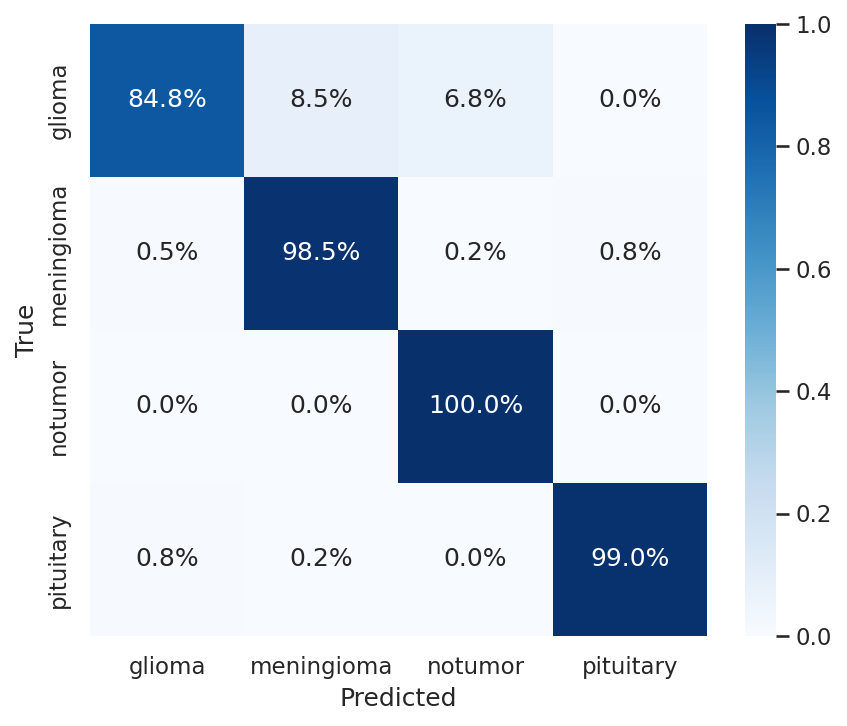


Training: densenet121
Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth



  0%|          | 0.00/30.8M [00:00<?, ?B/s]
100%|██████████| 30.8M/30.8M [00:00<00:00, 170MB/s]


densenet121: 6.96M params (6.96M trainable)
Epoch 1/20 - densenet121
loss 0.2788/0.1888 | acc 0.905/0.921 | val_f1 0.9212
Saved best checkpoint: /kaggle/working/checkpoints/best_brainmri_densenet121.pth
Epoch 2/20 - densenet121
loss 0.0909/0.1224 | acc 0.972/0.952 | val_f1 0.9513
Saved best checkpoint: /kaggle/working/checkpoints/best_brainmri_densenet121.pth
Epoch 3/20 - densenet121
loss 0.0648/0.0779 | acc 0.981/0.973 | val_f1 0.9732
Saved best checkpoint: /kaggle/working/checkpoints/best_brainmri_densenet121.pth
Epoch 4/20 - densenet121
loss 0.0441/0.0453 | acc 0.987/0.980 | val_f1 0.9804
Saved best checkpoint: /kaggle/working/checkpoints/best_brainmri_densenet121.pth
Epoch 5/20 - densenet121
loss 0.0336/0.0495 | acc 0.990/0.982 | val_f1 0.9822
Saved best checkpoint: /kaggle/working/checkpoints/best_brainmri_densenet121.pth
Epoch 6/20 - densenet121
loss 0.0248/0.0552 | acc 0.993/0.977 | val_f1 0.9768
Epoch 7/20 - densenet121
loss 0.0153/0.0564 | acc 0.997/0.979 | val_f1 0.9786
Epoch

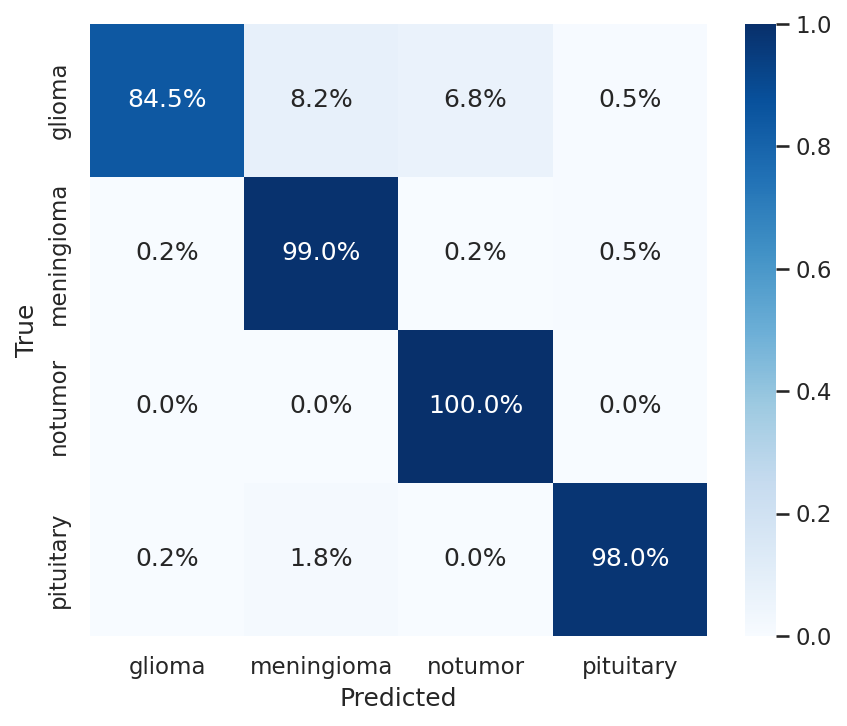

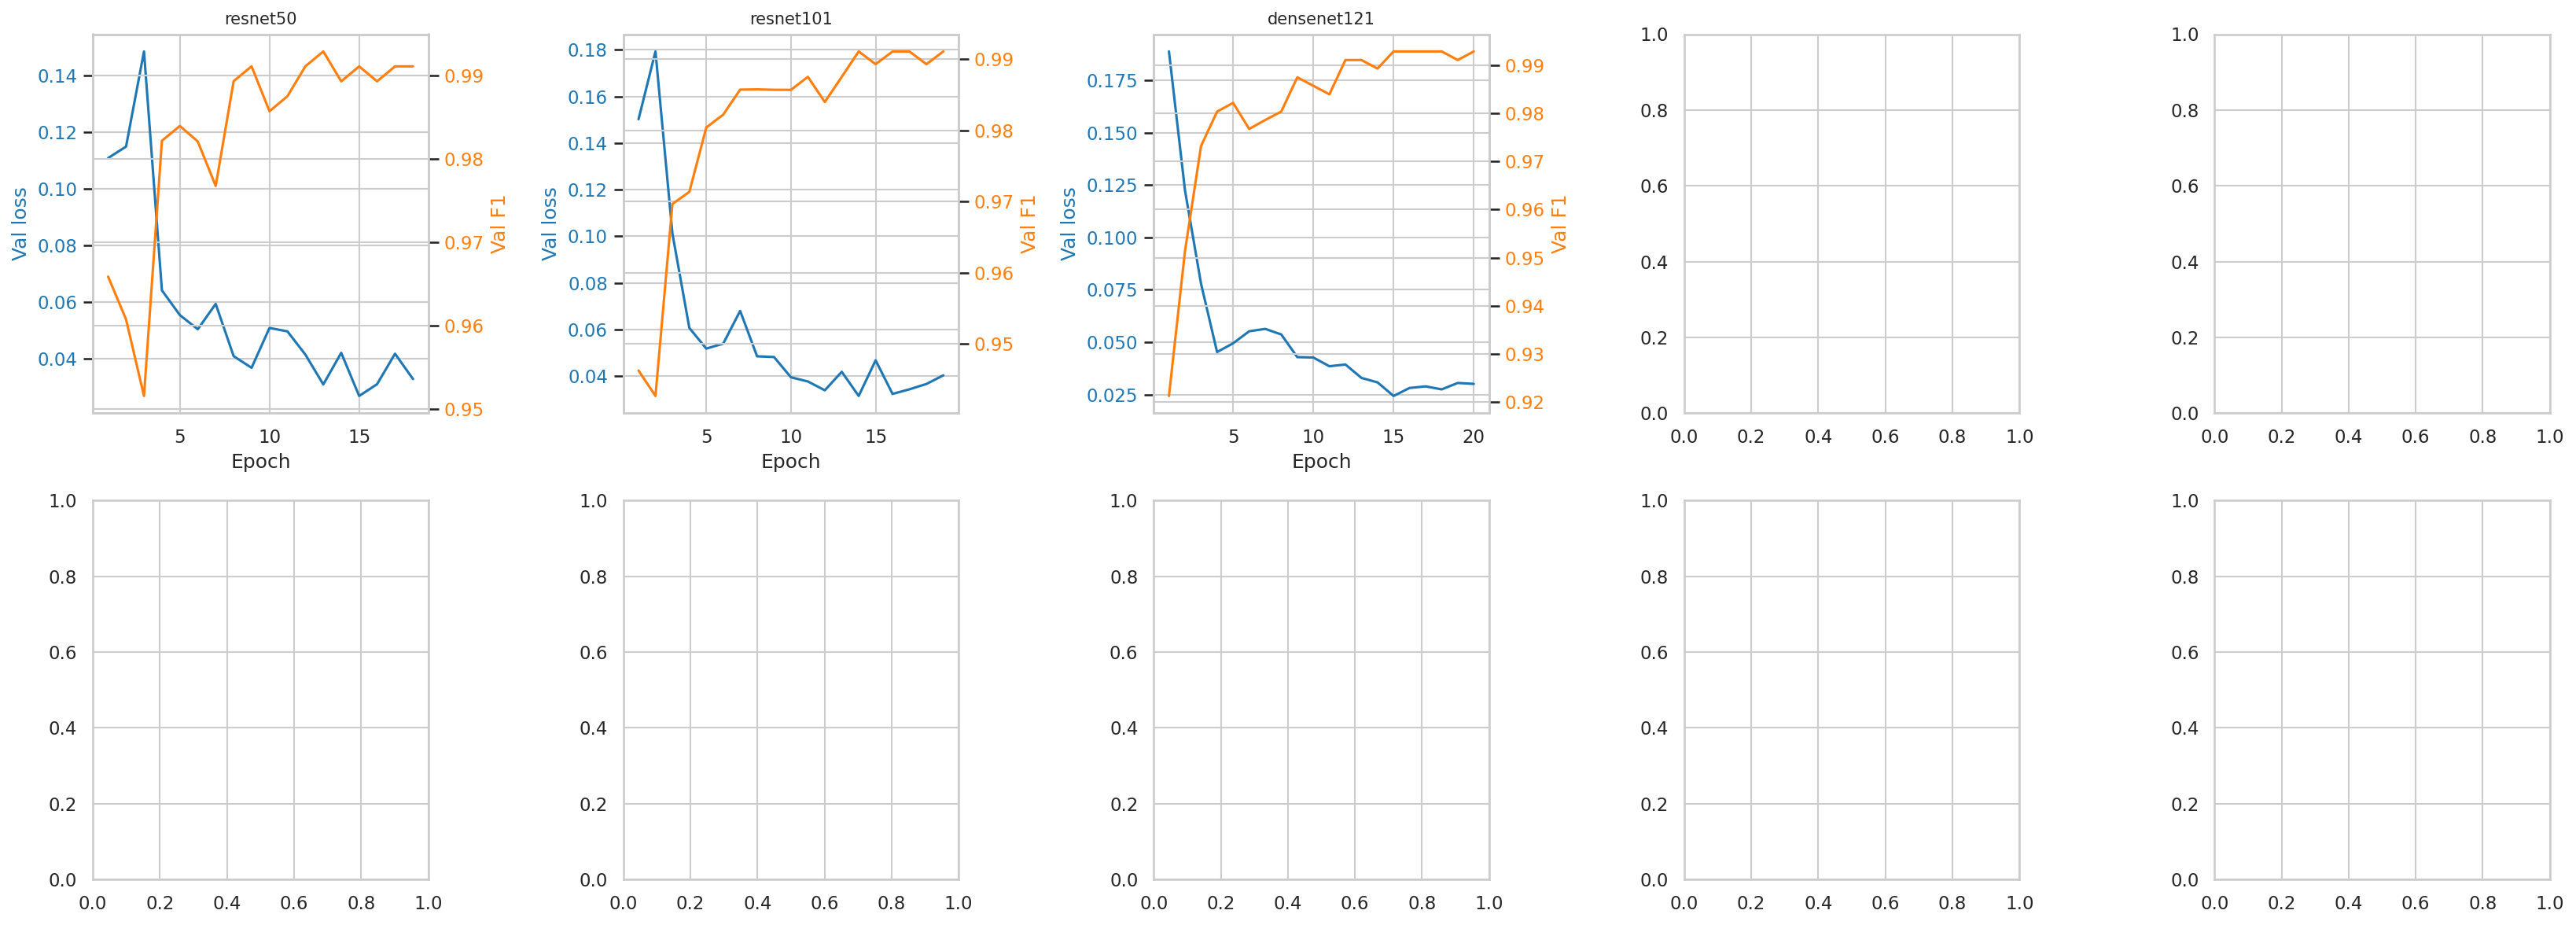

      model  test_accuracy  test_f1  test_auc  test_ece
   resnet50       0.951875 0.951082  0.986346  0.036028
  resnet101       0.955625 0.954814  0.990738  0.033954
densenet121       0.953750 0.952998  0.988292  0.036174
✓ Section 6 complete


In [9]:
all_histories = {}
baseline_results = []
baseline_confusions = {}
criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))

for model_name in tqdm(MODELS, desc='Training models'):
    print(f'\n{"="*60}')
    print(f'Training: {model_name}')
    print(f'{"="*60}')
    model, history, best_val_metrics = train_model(model_name, train_loader, val_loader, class_weights, CONFIG)
    all_histories[model_name] = history

    ckpt = f'{CONFIG["checkpoint_dir"]}/best_brainmri_{model_name}.pth'
    model.load_state_dict(torch.load(ckpt, map_location=device))
    test_metrics = evaluate(model, test_loader, criterion, device, CONFIG['num_classes'], CONFIG['class_names'])
    T_val, ece_ts = temperature_scale(
        model, val_loader, device, CONFIG['num_classes']
    )
    print(
        f"  Temperature={T_val:.3f}  ECE_baseline={test_metrics['ece']:.4f}  "
        f"ECE_temp_scaled={ece_ts:.4f}"
    )
    ece = test_metrics['ece']
    y_true, y_pred = test_metrics['labels'], test_metrics['preds']
    cm = confusion_matrix(y_true, y_pred, labels=list(range(CONFIG['num_classes'])))
    baseline_confusions[model_name] = cm
    precision, recall, f1, support = precision_recall_fscore_support(
        y_true, y_pred, labels=list(range(CONFIG['num_classes'])), zero_division=0
    )
    per_class_metrics = {}
    for i, name in enumerate(CONFIG['class_names']):
        per_class_metrics[f'{name}_precision'] = precision[i]
        per_class_metrics[f'{name}_recall'] = recall[i]
        per_class_metrics[f'{name}_f1'] = f1[i]

    baseline_results.append({
        'model': model_name,
        'val_acc': best_val_metrics['val_acc'],
        'val_f1': best_val_metrics['val_f1'],
        'val_auc': best_val_metrics['val_auc'],
        'val_ece': best_val_metrics['val_ece'],
        'test_accuracy': test_metrics['accuracy'],
        'test_f1': test_metrics['f1'],
        'test_auc': test_metrics['auc'],
        'test_ece': ece,
        'temperature': T_val,
        'test_ece_temp_scaled': ece_ts,
        **per_class_metrics
    })
    plot_confusion_matrix(cm, CONFIG['class_names'], model_name, save=True)
    del model
    torch.cuda.empty_cache()
    gc.collect()

baseline_df = pd.DataFrame(baseline_results)
baseline_df.to_csv(f'{CONFIG["results_dir"]}/baseline_results.csv', index=False)

fig, axes = plt.subplots(2, 5, figsize=(22, 8), dpi=150)
for ax, model_name in zip(axes.ravel(), MODELS):
    hist = all_histories.get(model_name, {})
    epochs = np.arange(1, len(hist.get('val_loss', [])) + 1)
    ax.plot(epochs, hist.get('val_loss', []), color='tab:blue', label='Val loss')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Val loss', color='tab:blue')
    ax.tick_params(axis='y', labelcolor='tab:blue')
    ax2 = ax.twinx()
    ax2.plot(epochs, hist.get('val_f1', []), color='tab:orange', label='Val F1')
    ax2.set_ylabel('Val F1', color='tab:orange')
    ax2.tick_params(axis='y', labelcolor='tab:orange')
    ax.set_title(model_name, fontsize=10)
plt.tight_layout()
plt.savefig(f'{CONFIG["figures_dir"]}/fig2_training_curves.png', dpi=300, bbox_inches='tight')
plt.show()

print(baseline_df[['model','test_accuracy','test_f1','test_auc','test_ece']].to_string(index=False))
print("✓ Section 6 complete")


In [10]:
def extract_failures(model_name, test_loader, config):
    """Load a trained model, collect predictions and embeddings, and return misclassified samples."""
    model = get_model(model_name, config['num_classes'], pretrained=False)
    model.load_state_dict(torch.load(f'{config["checkpoint_dir"]}/best_brainmri_{model_name}.pth', map_location=device))
    model.eval()
    hook_handle, embedding_store = get_embedding_hook(model, model_name)
    rows = []
    with torch.no_grad():
        for images, labels, paths in tqdm(test_loader, desc=f'failures {model_name}', leave=False, disable=not config.get('show_batch_progress', False)):
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            logits = model(images)
            probs = torch.softmax(logits, dim=1).detach().cpu().numpy()
            preds = probs.argmax(axis=1)
            conf = probs.max(axis=1)
            emb = embedding_store['embedding'].numpy()
            for i in range(len(paths)):
                rows.append({
                    'image_path': paths[i],
                    'true_label': int(labels.detach().cpu().numpy()[i]),
                    'pred_label': int(preds[i]),
                    'confidence': float(conf[i]),
                    'prob_vector': ','.join(f'{p:.8f}' for p in probs[i]),
                    'embedding': ','.join(f'{x:.8f}' for x in emb[i].ravel()),
                })
    hook_handle.remove()
    all_preds_df = pd.DataFrame(rows)
    failures_df = all_preds_df[all_preds_df['true_label'] != all_preds_df['pred_label']].reset_index(drop=True)
    del model
    torch.cuda.empty_cache()
    gc.collect()
    return failures_df, all_preds_df


# Section 7 extracts validation-set failures for failure-aware targeting.
all_failures = {}
all_predictions = {}
for model_name in tqdm(MODELS, desc='Extracting failures'):
    failures_df, all_preds_df = extract_failures(model_name, val_loader, CONFIG)
    all_failures[model_name] = failures_df
    all_predictions[model_name] = all_preds_df
    failures_df.to_csv(f'{CONFIG["results_dir"]}/failures_brainmri_{model_name}.csv', index=False)
    all_preds_df.to_csv(f'{CONFIG["results_dir"]}/predictions_brainmri_{model_name}.csv', index=False)
    print(f'{model_name}: {len(failures_df)} failures ({len(failures_df)/max(len(all_preds_df),1)*100:.1f}%)')

print("✓ Section 7 complete")


Extracting failures:   0%|          | 0/3 [00:00<?, ?it/s]

resnet50: 23.52M params (23.52M trainable)
resnet50: 4 failures (0.7%)
resnet101: 42.51M params (42.51M trainable)
resnet101: 5 failures (0.9%)
densenet121: 6.96M params (6.96M trainable)
densenet121: 4 failures (0.7%)
✓ Section 7 complete



──────────────────────────────────────────────────
Clustering → resnet50
  [resnet50] parsed 4 × 2048d in 0.00s
  PCA (3d) var=1.000 | 0.03s
  NOTE: KMeans clustering -> PCA-3d space (not UMAP)
  UMAP used ONLY for 2D visualization
  PCA-2D 2D projection: 0.00s
  KMeans sweep (2 values): 0.11s
  GMM BIC skipped (too few samples: 4)
  Final cluster (K=2): 0.04s
  TOTAL clustering time: 0.20s


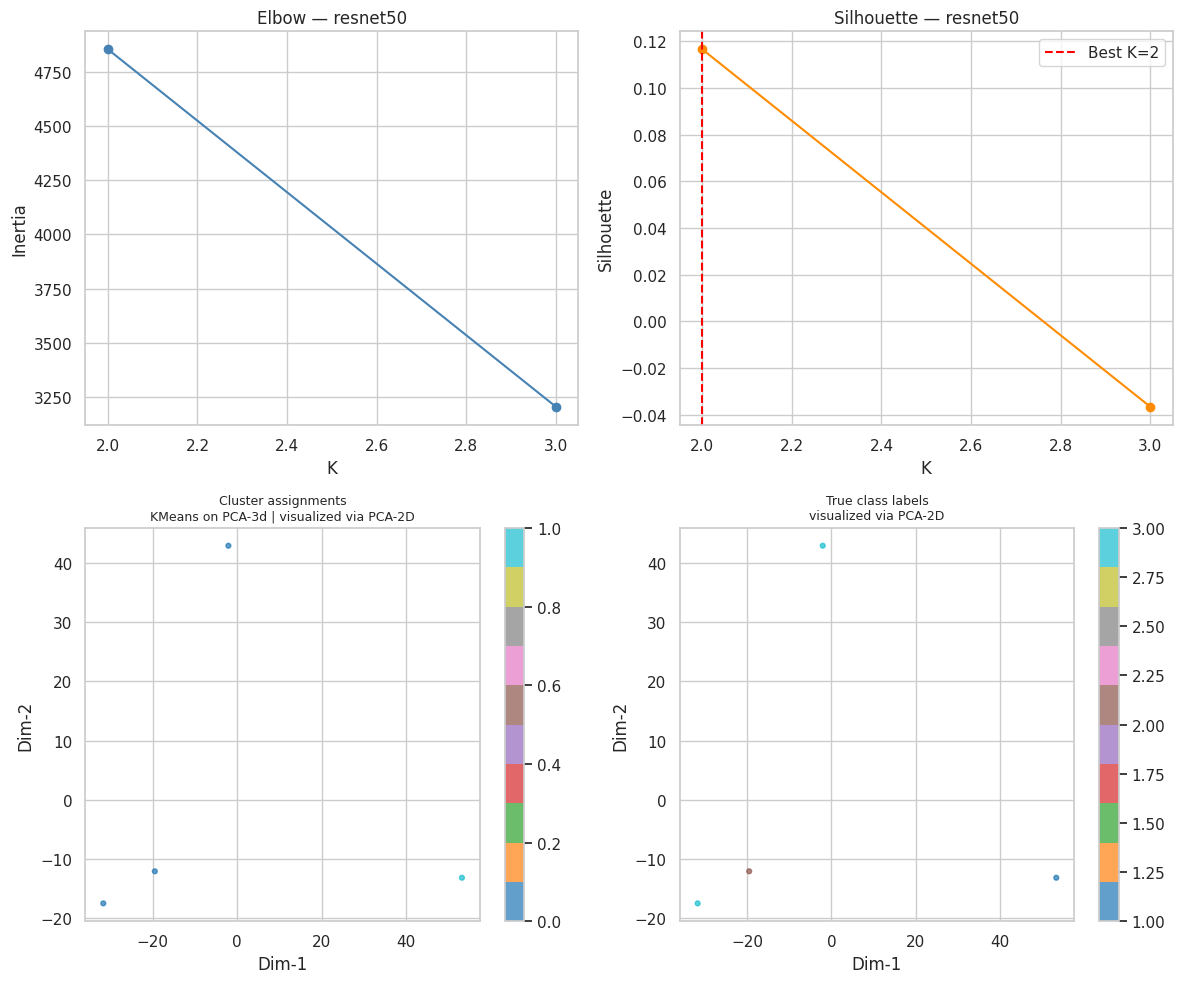

  Saved: /kaggle/working/figures/clustering_resnet50.png
  Cluster ARI across seeds: [1.0, 1.0, -0.333] -> mean=0.556
  → Best K=2  |  Silhouette=0.117

──────────────────────────────────────────────────
Clustering → resnet101
  [resnet101] parsed 5 × 2048d in 0.00s
  PCA (4d) var=1.000 | 0.00s
  NOTE: KMeans clustering -> PCA-4d space (not UMAP)
  UMAP used ONLY for 2D visualization
  PCA-2D 2D projection: 0.00s
  KMeans sweep (3 values): 0.02s
  GMM BIC skipped (too few samples: 5)
  Final cluster (K=3): 0.01s
  TOTAL clustering time: 0.03s


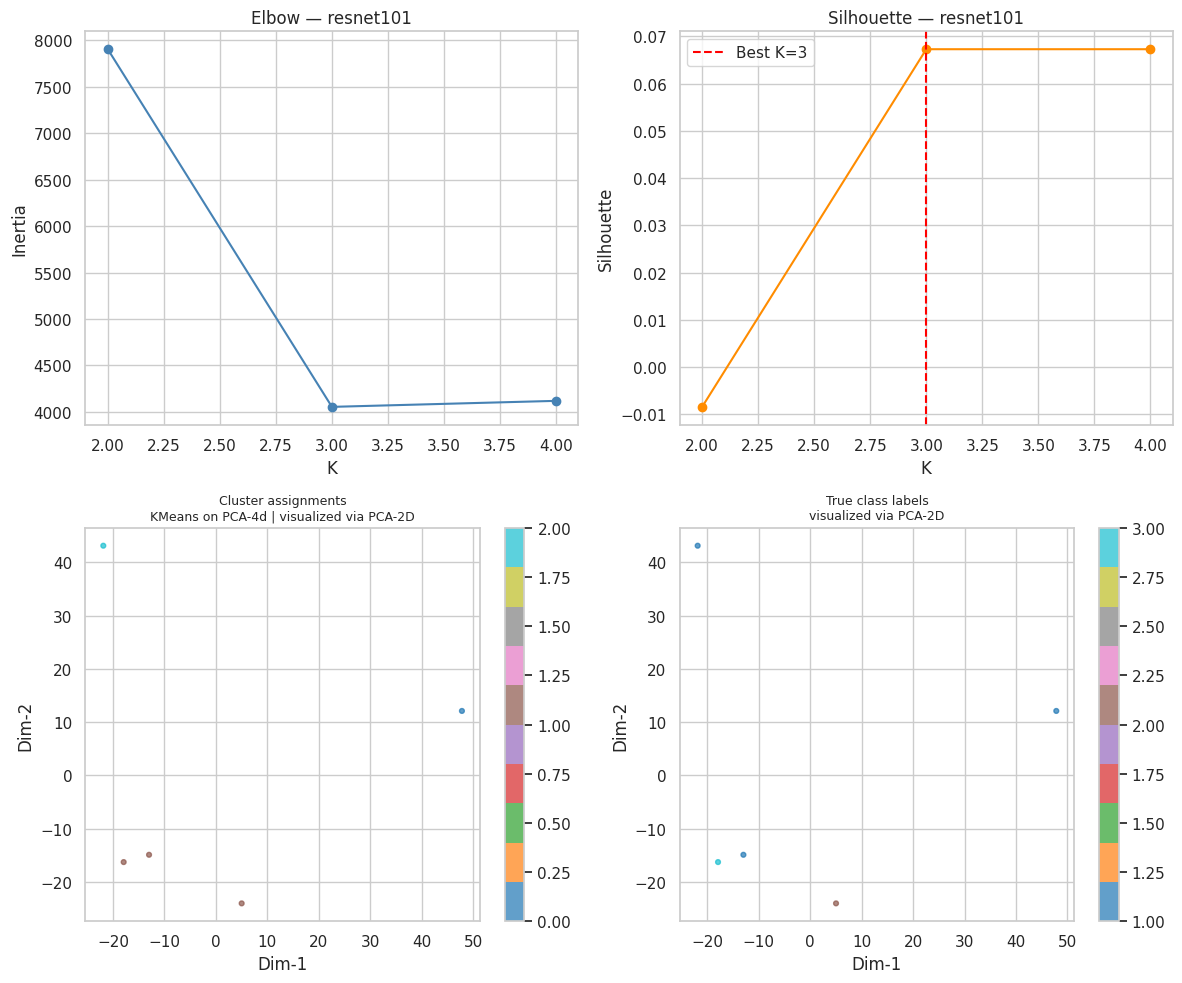

  Saved: /kaggle/working/figures/clustering_resnet101.png
  Cluster ARI across seeds: [0.048, 0.444, -0.429] -> mean=0.021
  → Best K=3  |  Silhouette=0.067

──────────────────────────────────────────────────
Clustering → densenet121
  [densenet121] parsed 4 × 1024d in 0.00s
  PCA (3d) var=1.000 | 0.00s
  NOTE: KMeans clustering -> PCA-3d space (not UMAP)
  UMAP used ONLY for 2D visualization
  PCA-2D 2D projection: 0.00s
  KMeans sweep (2 values): 0.01s
  GMM BIC skipped (too few samples: 4)
  Final cluster (K=3): 0.01s
  TOTAL clustering time: 0.02s


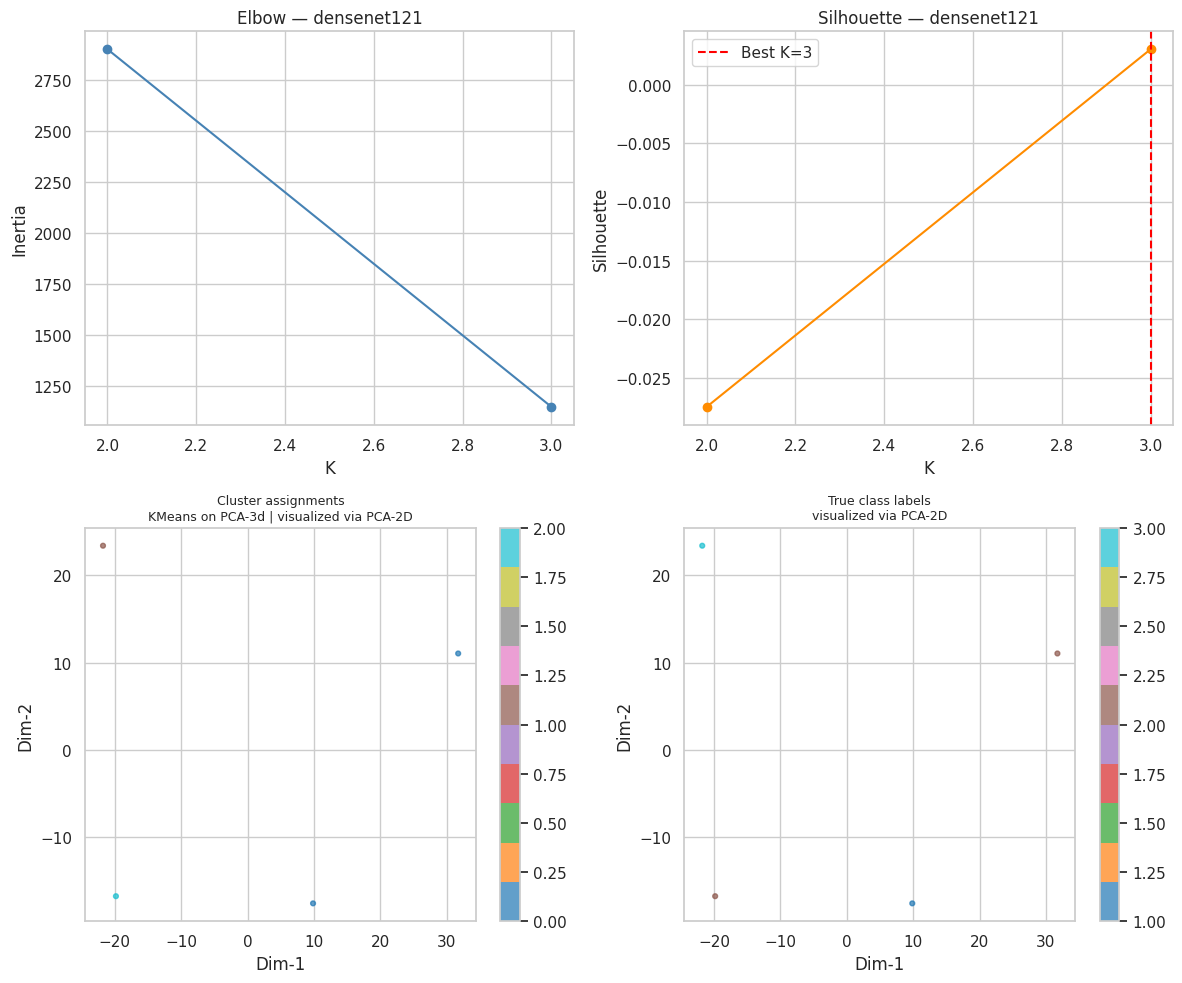

  Saved: /kaggle/working/figures/clustering_densenet121.png
  Cluster ARI across seeds: [1.0, -0.2, -0.2] -> mean=0.200
  → Best K=3  |  Silhouette=0.003

✓ Section 8 complete


In [11]:
def cluster_failures(failures_df, config, model_name):
    """
    Fast failure clustering: MiniBatchKMeans + aggressive PCA + 
    UMAP only when needed. Designed for Kaggle T4 GPU sessions.
    """
    import time

    # ── Guard ──────────────────────────────────────────────────────
    if len(failures_df) < 3:
        print(f"  Too few failures ({len(failures_df)}) — skipping: {model_name}")
        out = failures_df.copy()
        out['cluster'] = 0
        out['umap_x']  = 0.0
        out['umap_y']  = 0.0
        return out, 1, np.nan, 1, np.nan

    t0 = time.time()

    # ── FIX 1: Fast embedding parsing ──────────────────────────────
    # np.fromstring is slow for large arrays; use a list-comp + np.array
    raw = failures_df['embedding'].tolist()
    if isinstance(raw[0], str):
        embeddings = np.array(
            [np.fromstring(e, sep=',', dtype=np.float32) for e in raw],
            dtype=np.float32
        )
    else:                          # already arrays/lists
        embeddings = np.array(raw, dtype=np.float32)

    print(f"  [{model_name}] parsed {len(failures_df)} × {embeddings.shape[1]}d "
          f"in {time.time()-t0:.2f}s")

    # ── FIX 2: Aggressive PCA — cap at 32 components ───────────────
    # 50 PCA components costs ~2× more than 32 with almost no cluster benefit
    t1 = time.time()
    scaler = StandardScaler()
    E_scaled = scaler.fit_transform(embeddings)

    n_pca = min(
        32,                          # hard cap — was 50, unnecessary
        len(failures_df) - 1,
        E_scaled.shape[1]
    )
    pca = PCA(n_components=n_pca, random_state=config['seed'], svd_solver='randomized')
    E_pca = pca.fit_transform(E_scaled).astype(np.float32)
    print(f"  PCA ({n_pca}d) var={pca.explained_variance_ratio_.sum():.3f} "
          f"| {time.time()-t1:.2f}s")
    print(f"  NOTE: KMeans clustering -> PCA-{n_pca}d space (not UMAP)")
    print("  UMAP used ONLY for 2D visualization")

    # ── FIX 3: UMAP only when sample count justifies it ────────────
    # Skip UMAP entirely for small failure sets; use PCA-2D
    # For large sets use fast UMAP settings (fewer epochs, less neighbors)
    t2 = time.time()
    UMAP_THRESHOLD = config.get('small_failure_umap_threshold', 300)

    if len(failures_df) < UMAP_THRESHOLD:
        E_2d = E_pca[:, :2]
        proj_method = 'PCA-2D'
    else:
        import umap as umap_lib
        reducer = umap_lib.UMAP(
            n_neighbors   = min(10, max(2, len(failures_df) - 1)),  # was 15
            min_dist      = 0.1,
            n_components  = 2,
            random_state  = config['seed'],
            low_memory    = True,
            n_epochs      = 50,        # was 100 — halved; visually identical
            metric        = 'euclidean',
            n_jobs        = 1          # deterministic on Kaggle
        )
        # FIX 4: Run UMAP on PCA-16d not PCA-32d (faster, same layout)
        E_umap_input = E_pca[:, :16] if E_pca.shape[1] >= 16 else E_pca
        E_2d = reducer.fit_transform(E_umap_input).astype(np.float32)
        proj_method = 'UMAP'

    print(f"  {proj_method} 2D projection: {time.time()-t2:.2f}s")

    # ── FIX 5: MiniBatchKMeans + narrow K range ────────────────────
    # MiniBatchKMeans is 3-5× faster than KMeans on >200 samples
    # Also cap k_range at 6 — silhouette rarely improves beyond that
    t3 = time.time()
    from sklearn.cluster import MiniBatchKMeans

    k_range_full = list(config.get('k_range', range(2, 11)))
    k_range_fast = [k for k in k_range_full
                    if 2 <= k <= min(6, len(failures_df) - 1)]  # cap at 6

    if not k_range_fast:
        k_range_fast = [2] if len(failures_df) >= 2 else []

    inertias, silhouettes, valid_k = [], [], []

    # FIX 6: Subsample silhouette score for large failure sets
    # silhouette_score on 2000 points costs ~4s; on 500 it costs 0.3s
    MAX_SIL_SAMPLES = 500
    sil_idx = (
        np.random.RandomState(config['seed'])
               .choice(len(E_pca), size=min(MAX_SIL_SAMPLES, len(E_pca)),
                       replace=False)
        if len(E_pca) > MAX_SIL_SAMPLES else np.arange(len(E_pca))
    )
    E_sil = E_pca[sil_idx]

    for k in k_range_fast:
        km = MiniBatchKMeans(
            n_clusters    = k,
            random_state  = config['seed'],
            n_init        = 3,          # was 5-10
            batch_size    = min(256, len(failures_df)),
            max_iter      = 100
        )
        labels = km.fit_predict(E_pca)
        inertias.append(km.inertia_)
        valid_k.append(k)

        labels_sil = labels[sil_idx]
        if len(set(labels_sil)) > 1:
            silhouettes.append(silhouette_score(E_sil, labels_sil,
                                                 sample_size=None))
        else:
            silhouettes.append(np.nan)

    print(f"  KMeans sweep ({len(k_range_fast)} values): {time.time()-t3:.2f}s")

    # ── Select best K ───────────────────────────────────────────────
    if silhouettes and not np.all(np.isnan(silhouettes)):
        best_idx = int(np.nanargmax(silhouettes))
        best_k   = valid_k[best_idx]
        best_sil = silhouettes[best_idx]
    else:
        best_k   = 2
        best_sil = np.nan

    # GMM BIC - secondary K criterion
    from sklearn.mixture import GaussianMixture
    bic_scores = []
    best_k_bic = best_k

    if len(E_pca) >= 10 and k_range_fast:
        for k in k_range_fast:
            try:
                gmm = GaussianMixture(
                    n_components=k,
                    random_state=config['seed'],
                    max_iter=50,
                    n_init=2,
                    covariance_type='diag'
                )
                gmm.fit(E_pca)
                bic_scores.append(gmm.bic(E_pca))
            except Exception:
                bic_scores.append(np.inf)

        best_k_bic = k_range_fast[int(np.argmin(bic_scores))]

        if best_k_bic == best_k:
            print(f"  K consensus OK  silhouette={best_k}  BIC={best_k_bic}")
        else:
            print(
                f"  K conflict  silhouette={best_k}  BIC={best_k_bic} "
                f"-> keeping silhouette K"
            )
    else:
        print(f"  GMM BIC skipped (too few samples: {len(E_pca)})")

    # Final clustering with best K
    t4 = time.time()
    final_km = MiniBatchKMeans(
        n_clusters   = best_k,
        random_state = config['seed'],
        n_init       = 5,
        batch_size   = min(512, len(failures_df))
    )
    cluster_labels = final_km.fit_predict(E_pca)
    print(f"  Final cluster (K={best_k}): {time.time()-t4:.2f}s")
    print(f"  TOTAL clustering time: {time.time()-t0:.2f}s")

    # ── Attach results ──────────────────────────────────────────────
    clustered = failures_df.copy()
    clustered['cluster'] = cluster_labels
    clustered['umap_x']  = E_2d[:, 0]
    clustered['umap_y']  = E_2d[:, 1]

    # ── Plots ───────────────────────────────────────────────────────
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))

    if len(valid_k) > 1:
        axes[0, 0].plot(valid_k, inertias, marker='o', color='steelblue')
    axes[0, 0].set_xlabel('K')
    axes[0, 0].set_ylabel('Inertia')
    axes[0, 0].set_title(f'Elbow — {model_name}')

    if len(valid_k) > 1:
        axes[0, 1].plot(valid_k, silhouettes, marker='o', color='darkorange')
        axes[0, 1].axvline(best_k, color='red', linestyle='--',
                           label=f'Best K={best_k}')
        axes[0, 1].legend()
    axes[0, 1].set_xlabel('K')
    axes[0, 1].set_ylabel('Silhouette')
    axes[0, 1].set_title(f'Silhouette — {model_name}')

    sc1 = axes[1, 0].scatter(clustered['umap_x'], clustered['umap_y'],
                              c=clustered['cluster'],
                              cmap='tab10', s=12, alpha=0.7)
    axes[1, 0].set_title(
        f'Cluster assignments\n'
        f'KMeans on PCA-{n_pca}d | visualized via {proj_method}',
        fontsize=9
    )
    axes[1, 0].set_xlabel('Dim-1'); axes[1, 0].set_ylabel('Dim-2')
    plt.colorbar(sc1, ax=axes[1, 0])

    sc2 = axes[1, 1].scatter(clustered['umap_x'], clustered['umap_y'],
                              c=clustered['true_label'],
                              cmap='tab10', s=12, alpha=0.7)
    axes[1, 1].set_title(
        f'True class labels\n'
        f'visualized via {proj_method}',
        fontsize=9
    )
    axes[1, 1].set_xlabel('Dim-1'); axes[1, 1].set_ylabel('Dim-2')
    plt.colorbar(sc2, ax=axes[1, 1])

    plt.tight_layout()
    save_path = f"{config['figures_dir']}/clustering_{model_name}.png"
    plt.savefig(save_path, dpi=150, bbox_inches='tight')  # dpi=150 not 300 — saves time
    plt.show()
    print(f"  Saved: {save_path}")


    # ARI stability across 3 seeds
    from sklearn.metrics import adjusted_rand_score
    ari_scores = []
    for seed_i in [0, 1, 2]:
        km_check = MiniBatchKMeans(
            n_clusters=best_k,
            random_state=seed_i,
            n_init=3,
            batch_size=min(256, len(failures_df))
        )
        labels_check = km_check.fit_predict(E_pca)
        ari_scores.append(adjusted_rand_score(cluster_labels, labels_check))
    mean_ari = float(np.mean(ari_scores))
    print(
        f"  Cluster ARI across seeds: {[round(a, 3) for a in ari_scores]} "
        f"-> mean={mean_ari:.3f}"
    )
    clustered['mean_ari'] = mean_ari
    clustered['best_k_bic'] = best_k_bic


    return clustered, best_k, best_sil, best_k_bic, mean_ari


# ── Run clustering for all 10 models ───────────────────────────────
all_clustered    = {}
cluster_summaries = {}

for model_name in MODELS:
    print(f'\n{"─"*50}')
    print(f'Clustering → {model_name}')

    clustered_df, best_k, sil, best_k_bic, mean_ari = cluster_failures(
        all_failures[model_name], CONFIG, model_name
    )
    all_clustered[model_name]     = clustered_df
    cluster_summaries[model_name] = {
        'best_k': best_k,
        'best_k_bic': best_k_bic,
        'silhouette': sil,
        'mean_ari': mean_ari,
    }

    clustered_df.to_csv(
        f'{CONFIG["results_dir"]}/clustered_failures_{model_name}.csv',
        index=False
    )

    sil_str = f'{sil:.3f}' if not np.isnan(sil) else 'N/A'
    print(f'  → Best K={best_k}  |  Silhouette={sil_str}')

print('\n✓ Section 8 complete')



Profiling clusters: resnet50
  Image features: brightness=mean/255 | contrast=std/255 | sharpness=var(Laplacian) | foreground_size=fraction_pixels_above_mean_intensity
 cluster  n_samples  dominant_confusion  mean_confidence  per_cluster_ece
       0          3     notumor->glioma         0.959333         0.959333
       1          1 meningioma->notumor         0.642230         0.642230


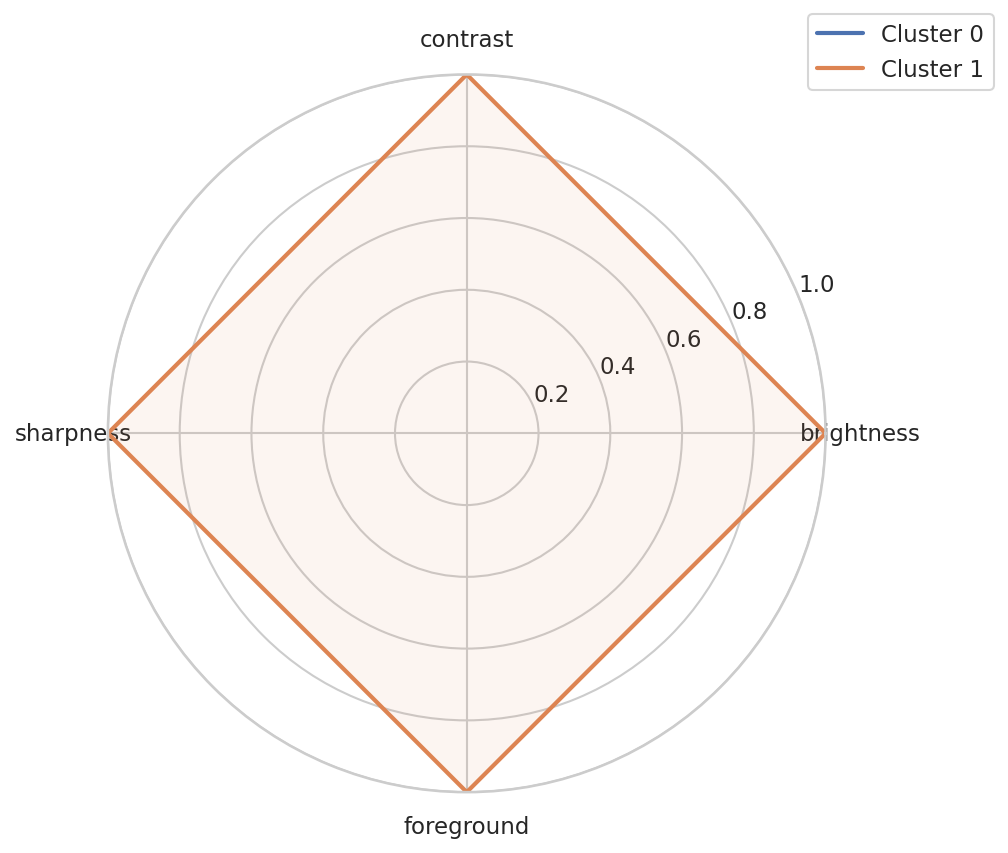


Profiling clusters: resnet101
  Image features: brightness=mean/255 | contrast=std/255 | sharpness=var(Laplacian) | foreground_size=fraction_pixels_above_mean_intensity
 cluster  n_samples    dominant_confusion  mean_confidence  per_cluster_ece
       0          1   meningioma->notumor         0.973958         0.973958
       1          3       notumor->glioma         0.887305         0.887305
       2          1 meningioma->pituitary         0.754019         0.754019


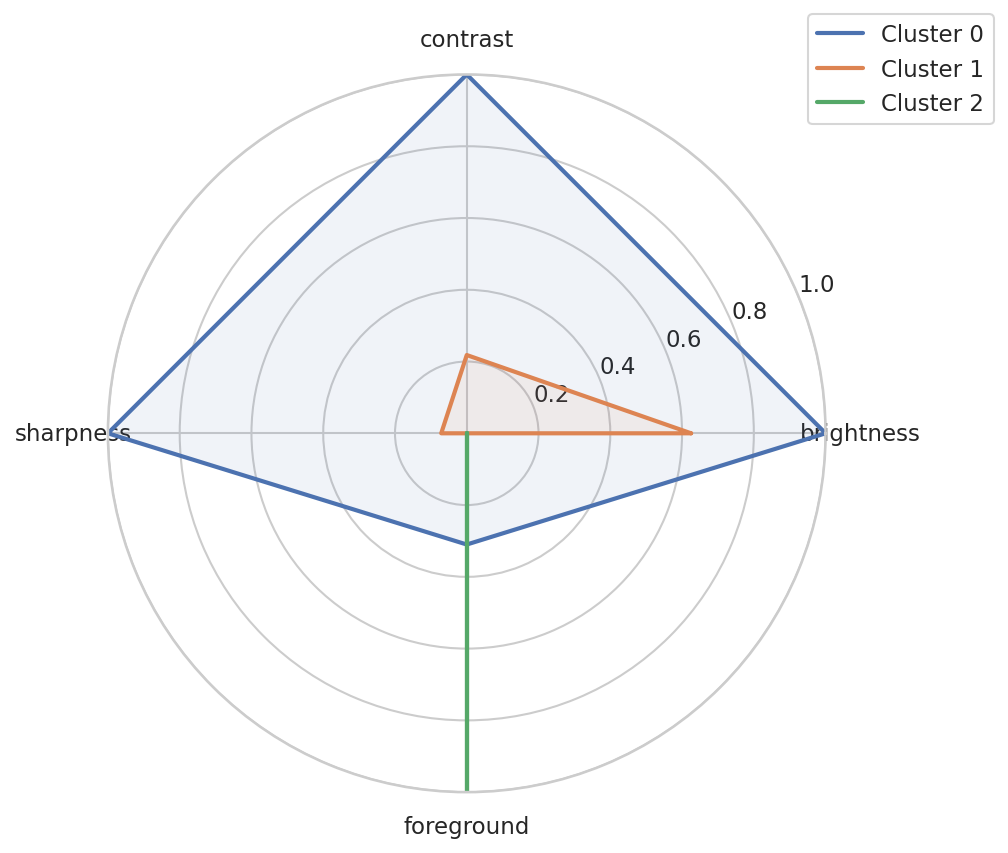


Profiling clusters: densenet121
  Image features: brightness=mean/255 | contrast=std/255 | sharpness=var(Laplacian) | foreground_size=fraction_pixels_above_mean_intensity
 cluster  n_samples    dominant_confusion  mean_confidence  per_cluster_ece
       0          2   meningioma->notumor         0.828807         0.828807
       1          1 pituitary->meningioma         0.992183         0.992183
       2          1       notumor->glioma         0.928173         0.928173


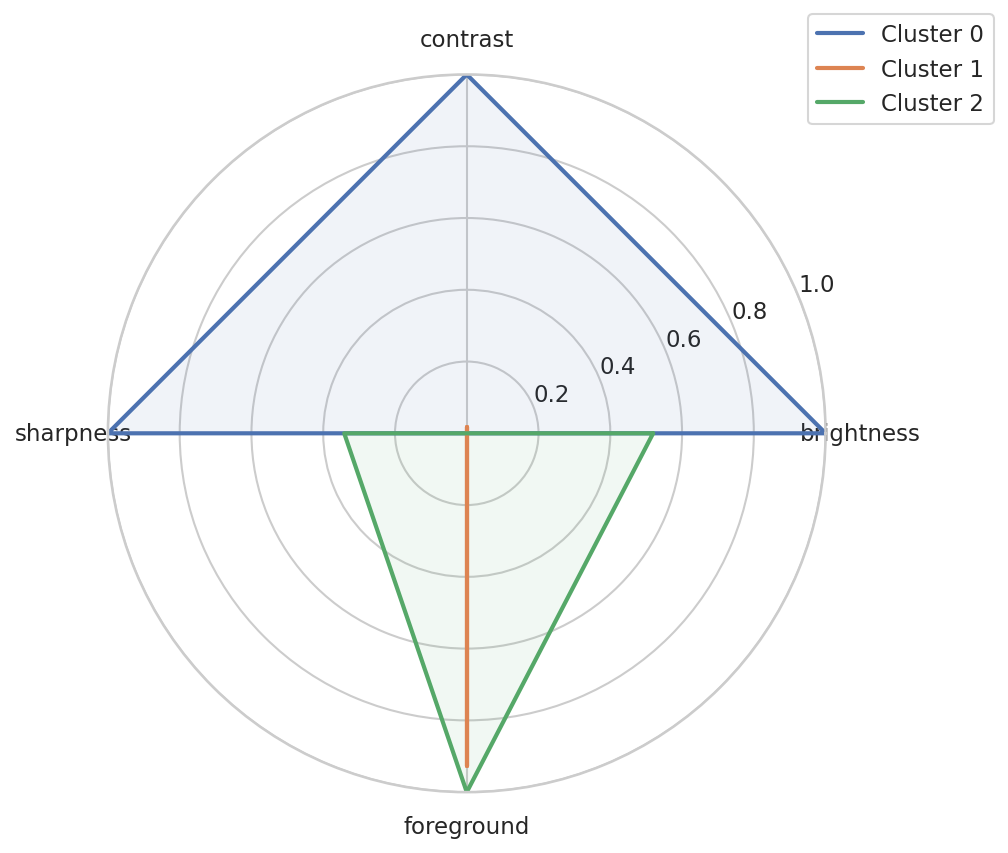

Cached image features: 7 unique images
✓ Section 9 complete


In [12]:
IMAGE_FEATURE_CACHE = {}


def compute_image_features(image_path, image_dir=None):
    """Compute cached brightness, contrast, sharpness, and foreground proxy from an image."""
    if image_path in IMAGE_FEATURE_CACHE:
        return IMAGE_FEATURE_CACHE[image_path]

    try:
        img = Image.open(image_path).convert('L').resize((224, 224))
        arr = np.asarray(img, dtype=np.float32)
    except Exception:
        features = {
            'brightness': np.nan,
            'contrast': np.nan,
            'sharpness': np.nan,
            'foreground_size': np.nan,
            'threshold_method': 'mean_intensity'
        }
        IMAGE_FEATURE_CACHE[image_path] = features
        return features

    brightness = float(arr.mean() / 255.0)
    contrast = float(arr.std() / 255.0)

    if ndimage is not None:
        sharpness = float(np.var(ndimage.laplace(arr)))
    else:
        gy, gx = np.gradient(arr)
        sharpness = float(np.var(gx) + np.var(gy))

    # Foreground proxy: mean-intensity threshold.
    # Modality-agnostic and parameter-free; reproducible across imaging modalities.
    # Near-uniform images (std <= 1.0) are assigned foreground_size=0
    # to avoid thresholding noise.
    if arr.std() > 1.0:
        thresh = float(arr.mean())
        foreground_size = float((arr > thresh).mean())
    else:
        foreground_size = 0.0

    features = {
        'brightness': brightness,
        'contrast': contrast,
        'sharpness': sharpness,
        'foreground_size': foreground_size,
        'threshold_method': 'mean_intensity'
    }

    IMAGE_FEATURE_CACHE[image_path] = features
    return features


def profile_clusters(clustered_df, model_name, config):
    """Summarize image characteristics and calibration for each failure cluster."""
    print(
        "  Image features: brightness=mean/255 | contrast=std/255 | "
        "sharpness=var(Laplacian) | "
        "foreground_size=fraction_pixels_above_mean_intensity"
    )
    rows = []

    if len(clustered_df) == 0:
        return pd.DataFrame()

    class_map = dict(enumerate(config['class_names']))

    for cluster_id, group in tqdm(
        clustered_df.groupby('cluster'),
        desc=f'profile {model_name}',
        leave=False,
        disable=not config.get('show_batch_progress', False)
    ):
        probs = np.stack(
            group['prob_vector'].apply(lambda x: np.fromstring(x, sep=','))
        )
        labels_arr = group['true_label'].values

        pairs = list(zip(group['true_label'], group['pred_label']))
        dominant_pair = Counter(pairs).most_common(1)[0][0]

        feature_rows = [
            compute_image_features(p, config.get('image_dir'))
            for p in group['image_path']
        ]
        features = pd.DataFrame(feature_rows)

        row = {
            'cluster': int(cluster_id),
            'n_samples': int(len(group)),
            'true_class_distribution': dict(Counter(group['true_label'].map(class_map))),
            'pred_class_distribution': dict(Counter(group['pred_label'].map(class_map))),
            'dominant_confusion': (
                f"{config['class_names'][dominant_pair[0]]}"
                f"->{config['class_names'][dominant_pair[1]]}"
            ),
            'mean_confidence': float(group['confidence'].mean()),
            'std_confidence': float(group['confidence'].std(ddof=0)),
            'per_cluster_ece': compute_ece(
                probs,
                labels_arr,
                config.get('ece_bins', 15)
            ),
        }

        for feat in ['brightness', 'contrast', 'sharpness', 'foreground_size']:
            row[f'{feat}_mean'] = float(features[feat].mean())
            row[f'{feat}_std'] = float(features[feat].std(ddof=0))

        rows.append(row)

    profile_df = pd.DataFrame(rows)

    print(
        profile_df[
            ['cluster', 'n_samples', 'dominant_confusion',
             'mean_confidence', 'per_cluster_ece']
        ].to_string(index=False)
    )

    feats = [
        'brightness_mean',
        'contrast_mean',
        'sharpness_mean',
        'foreground_size_mean'
    ]

    radar = profile_df[['cluster'] + feats].copy()

    for feat in feats:
        mn, mx = radar[feat].min(), radar[feat].max()
        if pd.isna(mn) or pd.isna(mx) or mx == mn:
            radar[feat] = 0.5
        else:
            radar[feat] = (radar[feat] - mn) / (mx - mn)

    labels = ['brightness', 'contrast', 'sharpness', 'foreground']
    angles = np.linspace(0, 2 * np.pi, len(labels), endpoint=False).tolist()
    angles += angles[:1]

    fig = plt.figure(figsize=(7, 7), dpi=150)
    ax = fig.add_subplot(111, polar=True)

    for _, row in radar.iterrows():
        values = [row[f] for f in feats]
        values += values[:1]

        ax.plot(
            angles,
            values,
            linewidth=2,
            label=f"Cluster {int(row['cluster'])}"
        )
        ax.fill(angles, values, alpha=0.08)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels)
    ax.set_ylim(0, 1)
    ax.legend(loc='upper right', bbox_to_anchor=(1.25, 1.1))

    plt.tight_layout()
    plt.savefig(
        f"{config['figures_dir']}/radar_{model_name}.png",
        dpi=300,
        bbox_inches='tight'
    )
    plt.show()

    return profile_df


all_profiles = {}

for model_name in MODELS:
    print(f'\nProfiling clusters: {model_name}')

    profile_df = profile_clusters(
        all_clustered[model_name],
        model_name,
        CONFIG
    )

    all_profiles[model_name] = profile_df

    profile_df.to_csv(
        f'{CONFIG["results_dir"]}/profile_brainmri_{model_name}.csv',
        index=False
    )

print(f"Cached image features: {len(IMAGE_FEATURE_CACHE)} unique images")
print("✓ Section 9 complete")


In [13]:
# ── Degradation guard thresholds (reads from CONFIG) ─────────────────
# Set these in CONFIG; defaults used if missing
# CONFIG['guard_f1_threshold']  = 0.98
# CONFIG['guard_acc_threshold'] = 0.98
# CONFIG['guard_ece_max_rise']  = 0.025


def build_failure_aware_dataset(train_df, clustered_df, profile_df, config, strategy='both'):
    """Create a retraining dataframe using cluster-informed weighting and/or selective augmentation."""
    out = train_df.copy()
    out['is_augmented'] = False
    out['sample_weight'] = 1.0

    if clustered_df is None or len(clustered_df) == 0 or profile_df is None or len(profile_df) == 0:
        return out

    cluster_counts     = clustered_df['cluster'].value_counts().to_dict()
    mean_cluster_count = np.mean(list(cluster_counts.values())) if cluster_counts else 1.0

    cluster_alpha = {
        k: max(1.0, v / max(mean_cluster_count, 1e-8))
        for k, v in cluster_counts.items()
    }

    path_to_cluster = dict(zip(clustered_df['image_path'], clustered_df['cluster']))

    cluster_to_true_labels = (
        clustered_df
        .groupby('cluster')['true_label']
        .apply(lambda s: set(s.tolist()))
        .to_dict()
    )

    path_overlap = out['image_path'].isin(set(clustered_df['image_path'])).sum()

    if strategy in ['selective', 'both']:
        high_clusters = [
            k for k, v in cluster_counts.items()
            if v > mean_cluster_count
        ]

        if len(high_clusters) == 0:
            high_clusters = list(cluster_counts.keys())

        high_paths = set(
            clustered_df[clustered_df['cluster'].isin(high_clusters)]['image_path']
        )

        source = out[out['image_path'].isin(high_paths)].copy()

        if len(source) == 0:
            high_labels = set()
            for cluster_id in high_clusters:
                high_labels.update(cluster_to_true_labels.get(cluster_id, set()))

            source = out[out['label'].isin(high_labels)].copy()
            print(
                "No train/test path overlap for selective augmentation; "
                f"using high-error true labels {sorted(high_labels)}."
            )

        max_aug_source = config.get('max_aug_source', 300)

        if len(source) > max_aug_source:
            if source['label'].nunique() > 1:
                source, _ = train_test_split(
                    source,
                    train_size=max_aug_source,
                    random_state=config['seed'],
                    stratify=source['label']
                )
                source = source.reset_index(drop=True)
            else:
                source = source.sample(
                    n=max_aug_source,
                    random_state=config['seed']
                ).reset_index(drop=True)
            print(f"Limited selective augmentation source to {max_aug_source} samples.")

        augmented = []
        for _ in range(config.get('aug_multiplier', 3)):
            aug = source.copy()
            aug['is_augmented'] = True
            augmented.append(aug)

        if augmented:
            out = pd.concat([out] + augmented, ignore_index=True)

        print(
            f"Selective augmentation: {len(source)} source rows, "
            f"{sum(len(a) for a in augmented)} augmented rows added"
        )

    if strategy in ['weighted', 'both']:
        if path_overlap > 0:
            out['sample_weight'] = out['image_path'].map(
                lambda p: cluster_alpha.get(path_to_cluster.get(p, None), 1.0)
            )
        else:
            label_weights = defaultdict(lambda: 1.0)
            for cluster_id, alpha in cluster_alpha.items():
                for label in cluster_to_true_labels.get(cluster_id, set()):
                    label_weights[label] = max(label_weights[label], alpha)

            out['sample_weight'] = out['label'].map(lambda y: label_weights[y])
            print(
                "No train/test path overlap for weighting; "
                f"using label-level failure weights {dict(label_weights)}."
            )

        print(
            f"Weighted sampling: sample weights range "
            f"{out['sample_weight'].min():.2f}–{out['sample_weight'].max():.2f}"
        )

    return out


def _run_degradation_guard(model, model_name, val_loader, criterion_retrain,
                            baseline_val_metrics, config, device,
                            baseline_ckpt, retrained_ckpt):
    """
    Evaluate retrained model on val set and compare against baseline.
    If ANY check fails → revert model weights to baseline in-place.

    Returns
    -------
    guard_result : dict
        guard_triggered : bool
        kept            : 'retrained' | 'baseline'
        checks          : dict of check-name → description string
        reason          : str of failed checks joined by ' | ', or None
    """
    val_retrained = evaluate(
        model, val_loader, criterion_retrain,
        device, config['num_classes'], config['class_names']
    )

    baseline_f1 = baseline_val_metrics['val_f1']
    use_weak = baseline_f1 < config.get('guard_weak_baseline_f1', 0.55)

    if use_weak:
        max_f1_drop = config.get('guard_weak_f1_max_drop', 0.04)
        max_acc_drop = config.get('guard_weak_acc_max_drop', 0.04)
        max_ece_rise = config.get('guard_weak_ece_max_rise', 0.04)
        tier = 'WEAK'
    else:
        max_f1_drop = config.get('guard_f1_max_drop', 0.02)
        max_acc_drop = config.get('guard_acc_max_drop', 0.02)
        max_ece_rise = config.get('guard_ece_max_rise', 0.025)
        tier = 'STRICT'

    f1_drop = baseline_val_metrics['val_f1'] - val_retrained['f1']
    acc_drop = baseline_val_metrics['val_acc'] - val_retrained['accuracy']
    ece_rise = val_retrained['ece'] - baseline_val_metrics['val_ece']

    checks = {
        'f1_ok': (
            f1_drop <= max_f1_drop,
            f"F1 drop {f1_drop:+.4f} "
            f"({'OK' if f1_drop <= max_f1_drop else 'FAIL'} "
            f"<= limit {max_f1_drop}) [{tier}]"
        ),
        'acc_ok': (
            acc_drop <= max_acc_drop,
            f"Acc drop {acc_drop:+.4f} "
            f"({'OK' if acc_drop <= max_acc_drop else 'FAIL'} "
            f"<= limit {max_acc_drop}) [{tier}]"
        ),
        'ece_ok': (
            ece_rise <= max_ece_rise,
            f"ECE rise {ece_rise:+.4f} "
            f"({'OK' if ece_rise <= max_ece_rise else 'FAIL'} "
            f"<= limit {max_ece_rise}) [{tier}]"
        ),
    }

    print(f"\n  Guard checks — {model_name}:")
    for name, (passed, msg) in checks.items():
        print(f"    {'✓' if passed else '✗'}  {msg}")

    failed = [msg for passed, msg in checks.values() if not passed]

    if failed:
        print(f"\n  ⚠️  Guard triggered — reverting {model_name} to baseline")
        model.load_state_dict(torch.load(baseline_ckpt, map_location=device))
        # overwrite retrained ckpt so downstream loads still work
        torch.save(model.state_dict(), retrained_ckpt)
        return {
            'guard_triggered': True,
            'kept'           : 'baseline',
            'checks'         : {k: v[1] for k, v in checks.items()},
            'reason'         : ' | '.join(failed),
        }

    print(f"\n  ✓ All checks passed — keeping retrained {model_name}")
    return {
        'guard_triggered': False,
        'kept'           : 'retrained',
        'checks'         : {k: v[1] for k, v in checks.items()},
        'reason'         : None,
    }


def retrain_model(model_name, train_loader_new, val_loader,
                  class_weights, config, baseline_val_metrics=None):
    """
    Warm-start from best baseline checkpoint and fine-tune with
    failure-aware data.

    Parameters
    ----------
    baseline_val_metrics : dict or None
        Keys: 'val_f1', 'val_acc', 'val_ece' from baseline evaluation.
        Pass None to skip the degradation guard entirely.

    Returns
    -------
    model        : best model state (baseline or retrained)
    history      : training history dict
    guard_result : dict with guard decision details
    """
    baseline_ckpt  = Path(config['checkpoint_dir']) / f'best_brainmri_{model_name}.pth'
    retrained_ckpt = Path(config['checkpoint_dir']) / f'retrained_brainmri_{model_name}.pth'

    # ── Warm start ───────────────────────────────────────────────────
    model = get_model(model_name, config['num_classes'], pretrained=False)
    model.load_state_dict(torch.load(baseline_ckpt, map_location=device))

    criterion_retrain = nn.CrossEntropyLoss(weight=class_weights.to(device))

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=config.get('retrain_lr', 5e-5),
        weight_decay=config['weight_decay']
    )

    retrain_epochs   = config.get('retrain_epochs', 1)
    retrain_patience = config.get('retrain_patience', 1)

    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=retrain_epochs
    )

    scaler           = GradScaler()
    history          = defaultdict(list)
    best_f1          = -np.inf
    patience_counter = 0

    # ── Training loop ────────────────────────────────────────────────
    for epoch in range(1, retrain_epochs + 1):
        print(f"  Retrain epoch {epoch}/{retrain_epochs} — {model_name}")

        train_loss, train_acc = train_one_epoch(
            model, train_loader_new, optimizer,
            criterion_retrain, scaler, device
        )

        val_metrics = evaluate(
            model, val_loader, criterion_retrain,
            device, config['num_classes'], config['class_names']
        )

        scheduler.step()

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_metrics['loss'])
        history['val_acc'].append(val_metrics['accuracy'])
        history['val_f1'].append(val_metrics['f1'])
        history['val_auc'].append(val_metrics['auc'])

        print(
            f"    loss={val_metrics['loss']:.4f}  "
            f"acc={val_metrics['accuracy']:.4f}  "
            f"F1={val_metrics['f1']:.4f}  "
            f"AUC={val_metrics['auc']:.4f}"
        )

        if val_metrics['f1'] > best_f1:
            best_f1          = val_metrics['f1']
            patience_counter = 0
            torch.save(model.state_dict(), retrained_ckpt)
            print(f"    ✓ checkpoint saved  (best val F1={best_f1:.4f})")
        else:
            patience_counter += 1
            print(f"    patience {patience_counter}/{retrain_patience}")
            if patience_counter >= retrain_patience:
                print(f"  Early stop at epoch {epoch}")
                break

    # ── Load best retrained weights before guard ─────────────────────
    model.load_state_dict(torch.load(retrained_ckpt, map_location=device))

    # ── Degradation guard ────────────────────────────────────────────
    if baseline_val_metrics is not None:
        guard_result = _run_degradation_guard(
            model, model_name, val_loader, criterion_retrain,
            baseline_val_metrics, config, device,
            baseline_ckpt, retrained_ckpt
        )
    else:
        print(f"\n  ⚠️  baseline_val_metrics not supplied — guard skipped for {model_name}")
        guard_result = {
            'guard_triggered': False,
            'kept'           : 'retrained',
            'checks'         : {},
            'reason'         : 'guard skipped — no baseline metrics supplied',
        }

    return model, dict(history), guard_result


# ── Retraining loop ──────────────────────────────────────────────────
improvement_results   = []
retrain_histories     = {}
retrained_confusions  = {}
retrained_predictions = {}
guard_log             = []          # ← new: full audit trail

for model_name in tqdm(MODELS, desc='Retraining'):

    family   = get_model_family(model_name)
    strategy = {
        'transformer': 'both',
        'efficient'  : 'weighted',
        'cnn'        : 'selective',
    }[family]

    print(f'\n{"═"*60}')
    print(f'Retraining → {model_name}  |  family={family}  |  strategy={strategy}')
    print(f'{"═"*60}')

    # ── Failure-aware training set ───────────────────────────────────
    new_train_df = build_failure_aware_dataset(
        train_df,
        all_clustered[model_name],
        all_profiles[model_name],
        CONFIG,
        strategy
    )

    new_train_loader, _, _, _ = get_dataloaders(
        new_train_df,
        test_df,
        CONFIG,
        val_df=val_loader.dataset.df
    )

    # ── Baseline val metrics for guard ───────────────────────────────
    # Prefer stored val metrics; fall back to test metrics if not saved
    baseline_row = baseline_df[baseline_df['model'] == model_name].iloc[0]

    baseline_val_metrics = {
        'val_f1' : baseline_row.get('val_f1',  baseline_row['test_f1']),
        'val_acc': baseline_row.get('val_acc', baseline_row['test_accuracy']),
        'val_ece': baseline_row.get('val_ece', baseline_row['test_ece']),
    }

    # ── Retrain + guard ──────────────────────────────────────────────
    retrained_model, history, guard_result = retrain_model(
        model_name,
        new_train_loader,
        val_loader,
        class_weights,
        CONFIG,
        baseline_val_metrics=baseline_val_metrics
    )

    retrain_histories[model_name] = history
    guard_log.append({**guard_result, 'model': model_name})

    # ── Test set evaluation ──────────────────────────────────────────
    retrain_metrics = evaluate(
        retrained_model,
        test_loader,
        criterion,
        device,
        CONFIG['num_classes'],
        CONFIG['class_names']
    )

    retrained_predictions[model_name] = retrain_metrics

    retrained_confusions[model_name] = confusion_matrix(
        retrain_metrics['labels'],
        retrain_metrics['preds'],
        labels=list(range(CONFIG['num_classes']))
    )

    # ── Deltas ───────────────────────────────────────────────────────
    delta_acc = (
        (retrain_metrics['accuracy'] - baseline_row['test_accuracy'])
        / max(baseline_row['test_accuracy'], 1e-8) * 100
    )
    delta_f1 = (
        (retrain_metrics['f1'] - baseline_row['test_f1'])
        / max(baseline_row['test_f1'], 1e-8) * 100
    )
    delta_auc = (
        (retrain_metrics['auc'] - baseline_row['test_auc'])
        / max(baseline_row['test_auc'], 1e-8) * 100
    )
    delta_ece = retrain_metrics['ece'] - baseline_row['test_ece']

    improvement_results.append({
        'model'          : model_name,
        'family'         : family,
        'strategy'       : strategy,
        # guard columns
        'guard_triggered': guard_result['guard_triggered'],
        'guard_kept'     : guard_result['kept'],
        'guard_reason'   : guard_result['reason'],
        # metrics
        'baseline_acc'   : baseline_row['test_accuracy'],
        'retrained_acc'  : retrain_metrics['accuracy'],
        'delta_acc_pct'  : delta_acc,
        'baseline_f1'    : baseline_row['test_f1'],
        'retrained_f1'   : retrain_metrics['f1'],
        'delta_f1_pct'   : delta_f1,
        'baseline_auc'   : baseline_row['test_auc'],
        'retrained_auc'  : retrain_metrics['auc'],
        'delta_auc_pct'  : delta_auc,
        'baseline_ece'   : baseline_row['test_ece'],
        'retrained_ece'  : retrain_metrics['ece'],
        'delta_ece'      : delta_ece,
    })

    del retrained_model
    torch.cuda.empty_cache()
    gc.collect()


# ── Save ─────────────────────────────────────────────────────────────
improvement_df = pd.DataFrame(improvement_results)
improvement_df.to_csv(
    f'{CONFIG["results_dir"]}/improvement_brainmri.csv', index=False
)

guard_df = pd.DataFrame(guard_log)
guard_df.to_csv(
    f'{CONFIG["results_dir"]}/guard_log_brainmri.csv', index=False
)

# ── Guard summary ─────────────────────────────────────────────────────
triggered = guard_df[guard_df['guard_triggered']]
passed    = guard_df[~guard_df['guard_triggered']]

print(f'\n{"═"*60}')
print(f'GUARD SUMMARY')
print(f'{"═"*60}')
print(f'  Passed   (retrained kept) : {len(passed)}/{len(MODELS)}')
print(f'  Triggered (reverted)      : {len(triggered)}/{len(MODELS)}')
if len(triggered) > 0:
    print(f'\n  Reverted models:')
    for _, row in triggered.iterrows():
        print(f'    ⚠️  {row["model"]:35s}  {row["reason"]}')

# ── Improvement summary ───────────────────────────────────────────────
print(f'\n{"═"*60}')
print('IMPROVEMENT SUMMARY')
print(f'{"═"*60}')
print(improvement_df[[
    'model', 'strategy', 'guard_kept',
    'baseline_acc', 'retrained_acc', 'delta_acc_pct',
    'baseline_f1',  'retrained_f1',  'delta_f1_pct',
    'delta_ece',
]].to_string(index=False))

print('\n✓ Section 10 complete')


Retraining:   0%|          | 0/3 [00:00<?, ?it/s]


════════════════════════════════════════════════════════════
Retraining → resnet50  |  family=cnn  |  strategy=selective
════════════════════════════════════════════════════════════
No train/test path overlap for selective augmentation; using high-error true labels [2, 3].
Limited selective augmentation source to 300 samples.
Selective augmentation: 300 source rows, 900 augmented rows added
resnet50: 23.52M params (23.52M trainable)
  Retrain epoch 1/10 — resnet50
    loss=0.0424  acc=0.9875  F1=0.9875  AUC=0.9998
    ✓ checkpoint saved  (best val F1=0.9875)
  Retrain epoch 2/10 — resnet50
    loss=0.0440  acc=0.9929  F1=0.9929  AUC=0.9997
    ✓ checkpoint saved  (best val F1=0.9929)
  Retrain epoch 3/10 — resnet50
    loss=0.0542  acc=0.9875  F1=0.9875  AUC=0.9996
    patience 1/3
  Retrain epoch 4/10 — resnet50
    loss=0.0548  acc=0.9875  F1=0.9875  AUC=0.9996
    patience 2/3
  Retrain epoch 5/10 — resnet50
    loss=0.0343  acc=0.9929  F1=0.9929  AUC=0.9999
    patience 3/3
  Earl

In [14]:

# Section 10b: Compute-matched Untargeted Control
# Same epochs, same LR, same schedule, but uniform sampling,
# no cluster weighting, no selective augmentation.
# This isolates the benefit of failure-aware targeting from additional training alone.

DATASET_NAME = 'brainmri'
DATASET_DISPLAY = 'Brain Tumor MRI'


def retrain_untargeted(model_name, train_loader, val_loader, class_weights, config):
    """Untargeted fine-tuning control: identical budget, no cluster info."""
    baseline_ckpt = Path(config['checkpoint_dir']) / f'best_brainmri_{model_name}.pth'
    control_ckpt = Path(config['checkpoint_dir']) / f'control_brainmri_{model_name}.pth'

    model = get_model(model_name, config['num_classes'], pretrained=False)
    model.load_state_dict(torch.load(baseline_ckpt, map_location=device))

    criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=config.get('retrain_lr', 5e-5),
        weight_decay=config['weight_decay']
    )
    retrain_epochs = config.get('retrain_epochs', 10)
    retrain_patience = config.get('retrain_patience', 3)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=retrain_epochs)
    scaler = GradScaler()
    best_f1, patience_counter = -np.inf, 0

    for epoch in range(1, retrain_epochs + 1):
        train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, scaler, device)
        val_metrics = evaluate(model, val_loader, criterion, device, config['num_classes'], config['class_names'])
        scheduler.step()
        if val_metrics['f1'] > best_f1:
            best_f1 = val_metrics['f1']
            patience_counter = 0
            torch.save(model.state_dict(), control_ckpt)
        else:
            patience_counter += 1
            if patience_counter >= retrain_patience:
                print(f"    Early stop at epoch {epoch}")
                break

    model.load_state_dict(torch.load(control_ckpt, map_location=device))
    test_metrics = evaluate(model, test_loader, criterion, device, config['num_classes'], config['class_names'])
    del model
    torch.cuda.empty_cache()
    gc.collect()
    return test_metrics


untargeted_results = []
for model_name in tqdm(MODELS, desc='Untargeted Control'):
    print(f"\nUntargeted control -> {model_name}")
    ctrl_metrics = retrain_untargeted(model_name, train_loader, val_loader, class_weights, CONFIG)
    baseline_row = baseline_df[baseline_df['model'] == model_name].iloc[0]
    delta_f1_ctrl = ((ctrl_metrics['f1'] - baseline_row['test_f1']) / max(baseline_row['test_f1'], 1e-8) * 100)
    untargeted_results.append({
        'model': model_name,
        'dataset': DATASET_NAME,
        'ctrl_f1': ctrl_metrics['f1'],
        'ctrl_acc': ctrl_metrics['accuracy'],
        'ctrl_ece': ctrl_metrics['ece'],
        'ctrl_auc': ctrl_metrics['auc'],
        'delta_f1_ctrl_pct': delta_f1_ctrl,
    })
    print(f"  ctrl F1={ctrl_metrics['f1']:.4f}  Delta F1={delta_f1_ctrl:+.2f}%")

untargeted_df = pd.DataFrame(untargeted_results)
untargeted_df.to_csv(f'{CONFIG["results_dir"]}/untargeted_control_{DATASET_NAME}.csv', index=False)
print("\nSection 10b complete - untargeted control saved")


Untargeted Control:   0%|          | 0/3 [00:00<?, ?it/s]


Untargeted control -> resnet50
resnet50: 23.52M params (23.52M trainable)
    Early stop at epoch 7
  ctrl F1=0.9537  Delta F1=+0.27%

Untargeted control -> resnet101
resnet101: 42.51M params (42.51M trainable)
    Early stop at epoch 7
  ctrl F1=0.9568  Delta F1=+0.21%

Untargeted control -> densenet121
densenet121: 6.96M params (6.96M trainable)
  ctrl F1=0.9613  Delta F1=+0.87%

Section 10b complete - untargeted control saved


Best model selected for detailed figures: resnet101


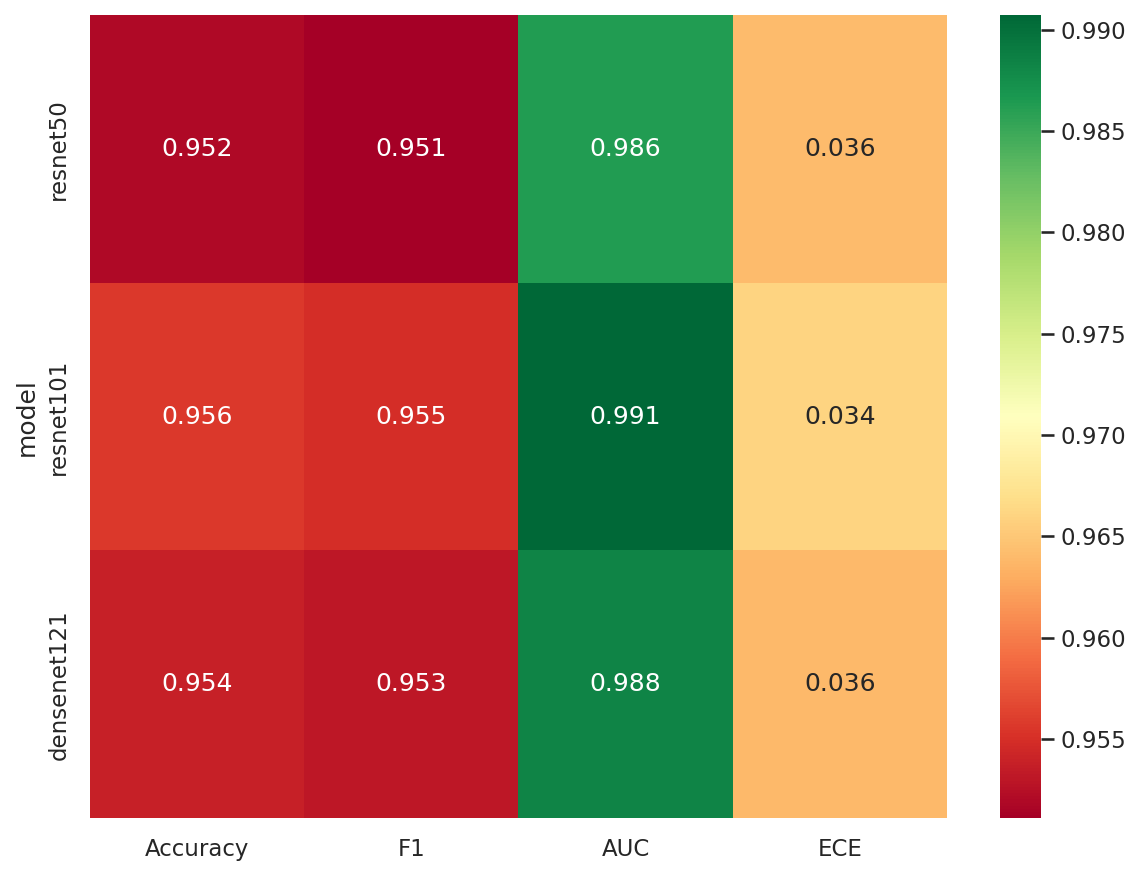

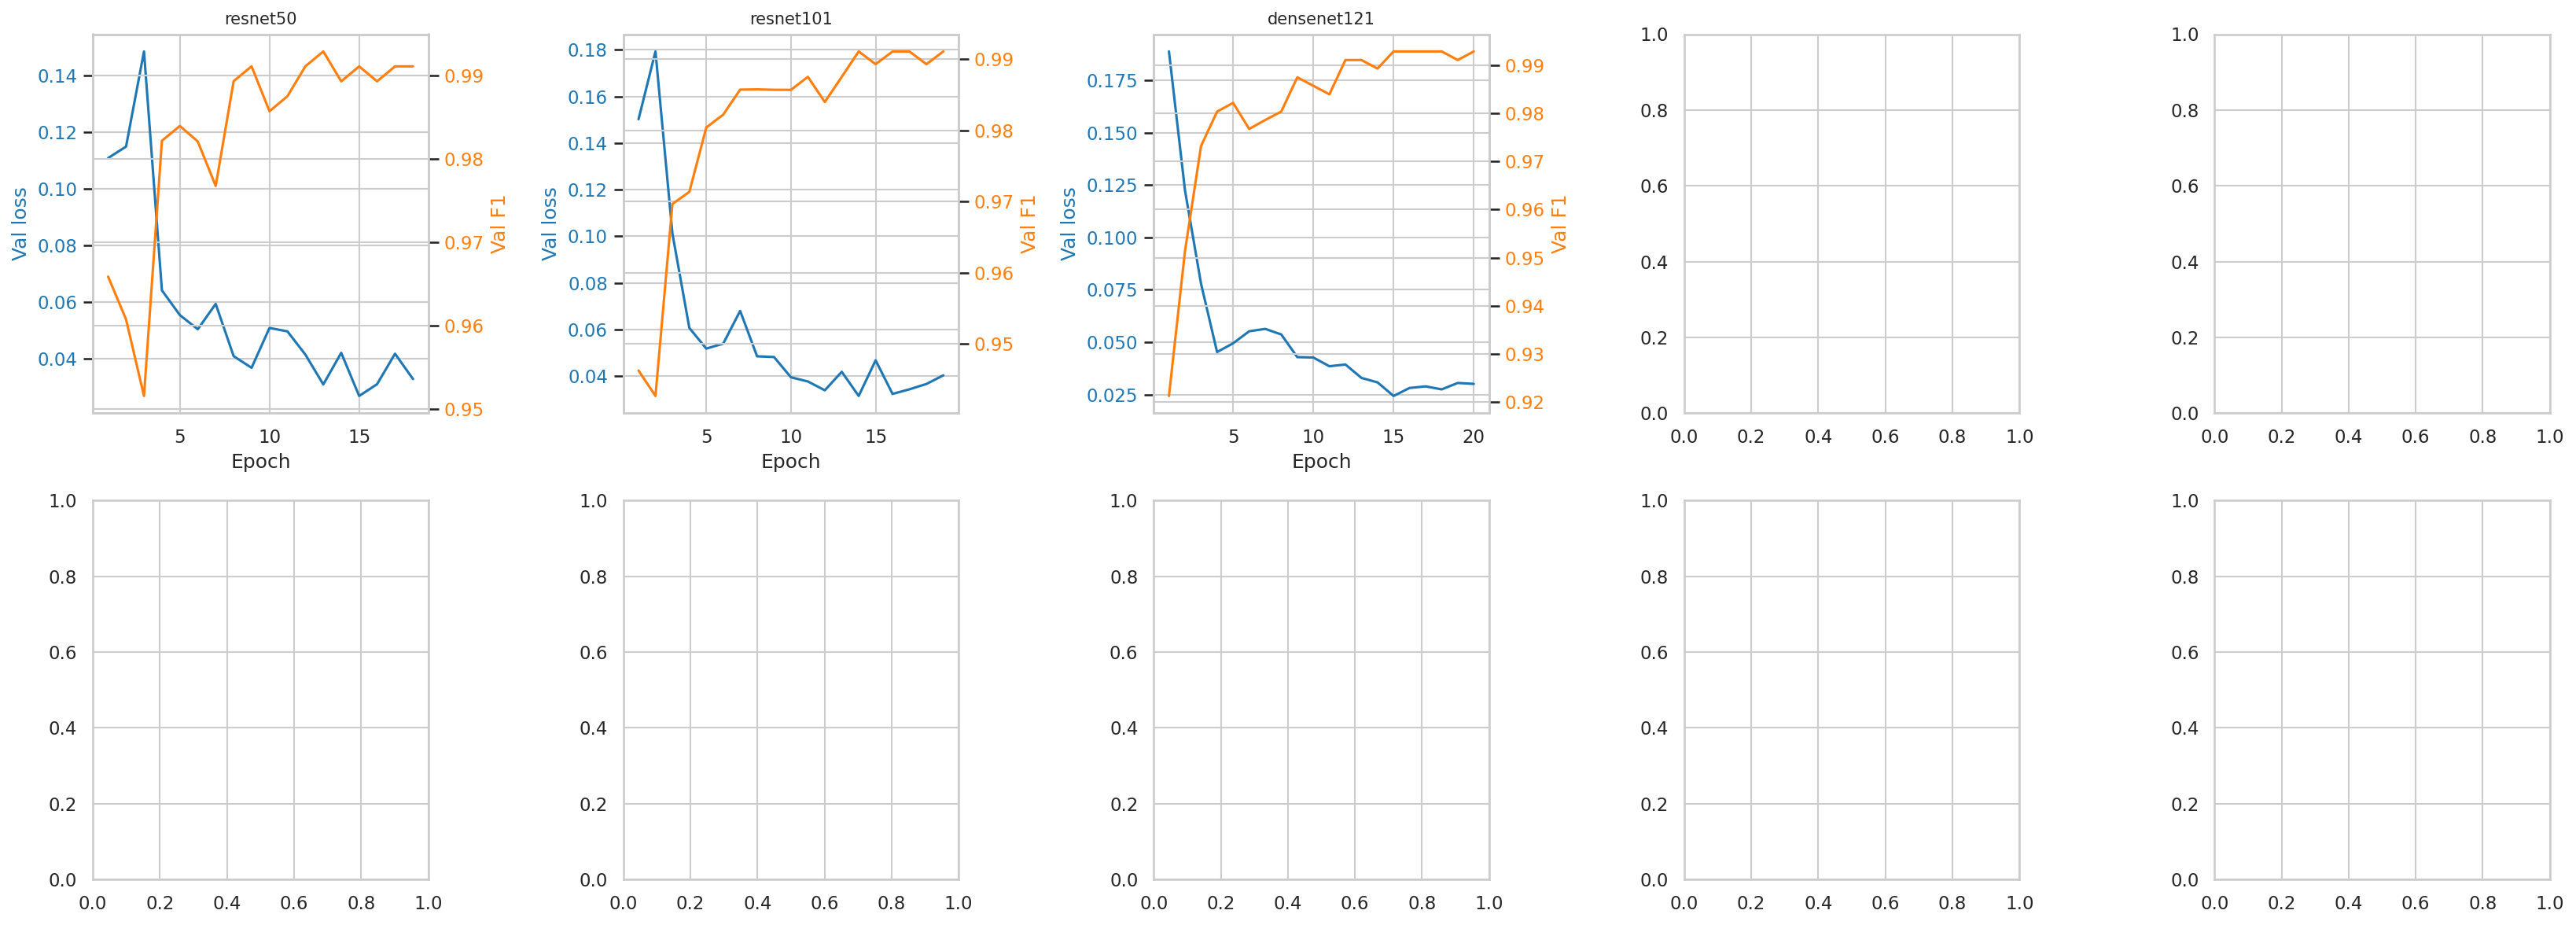

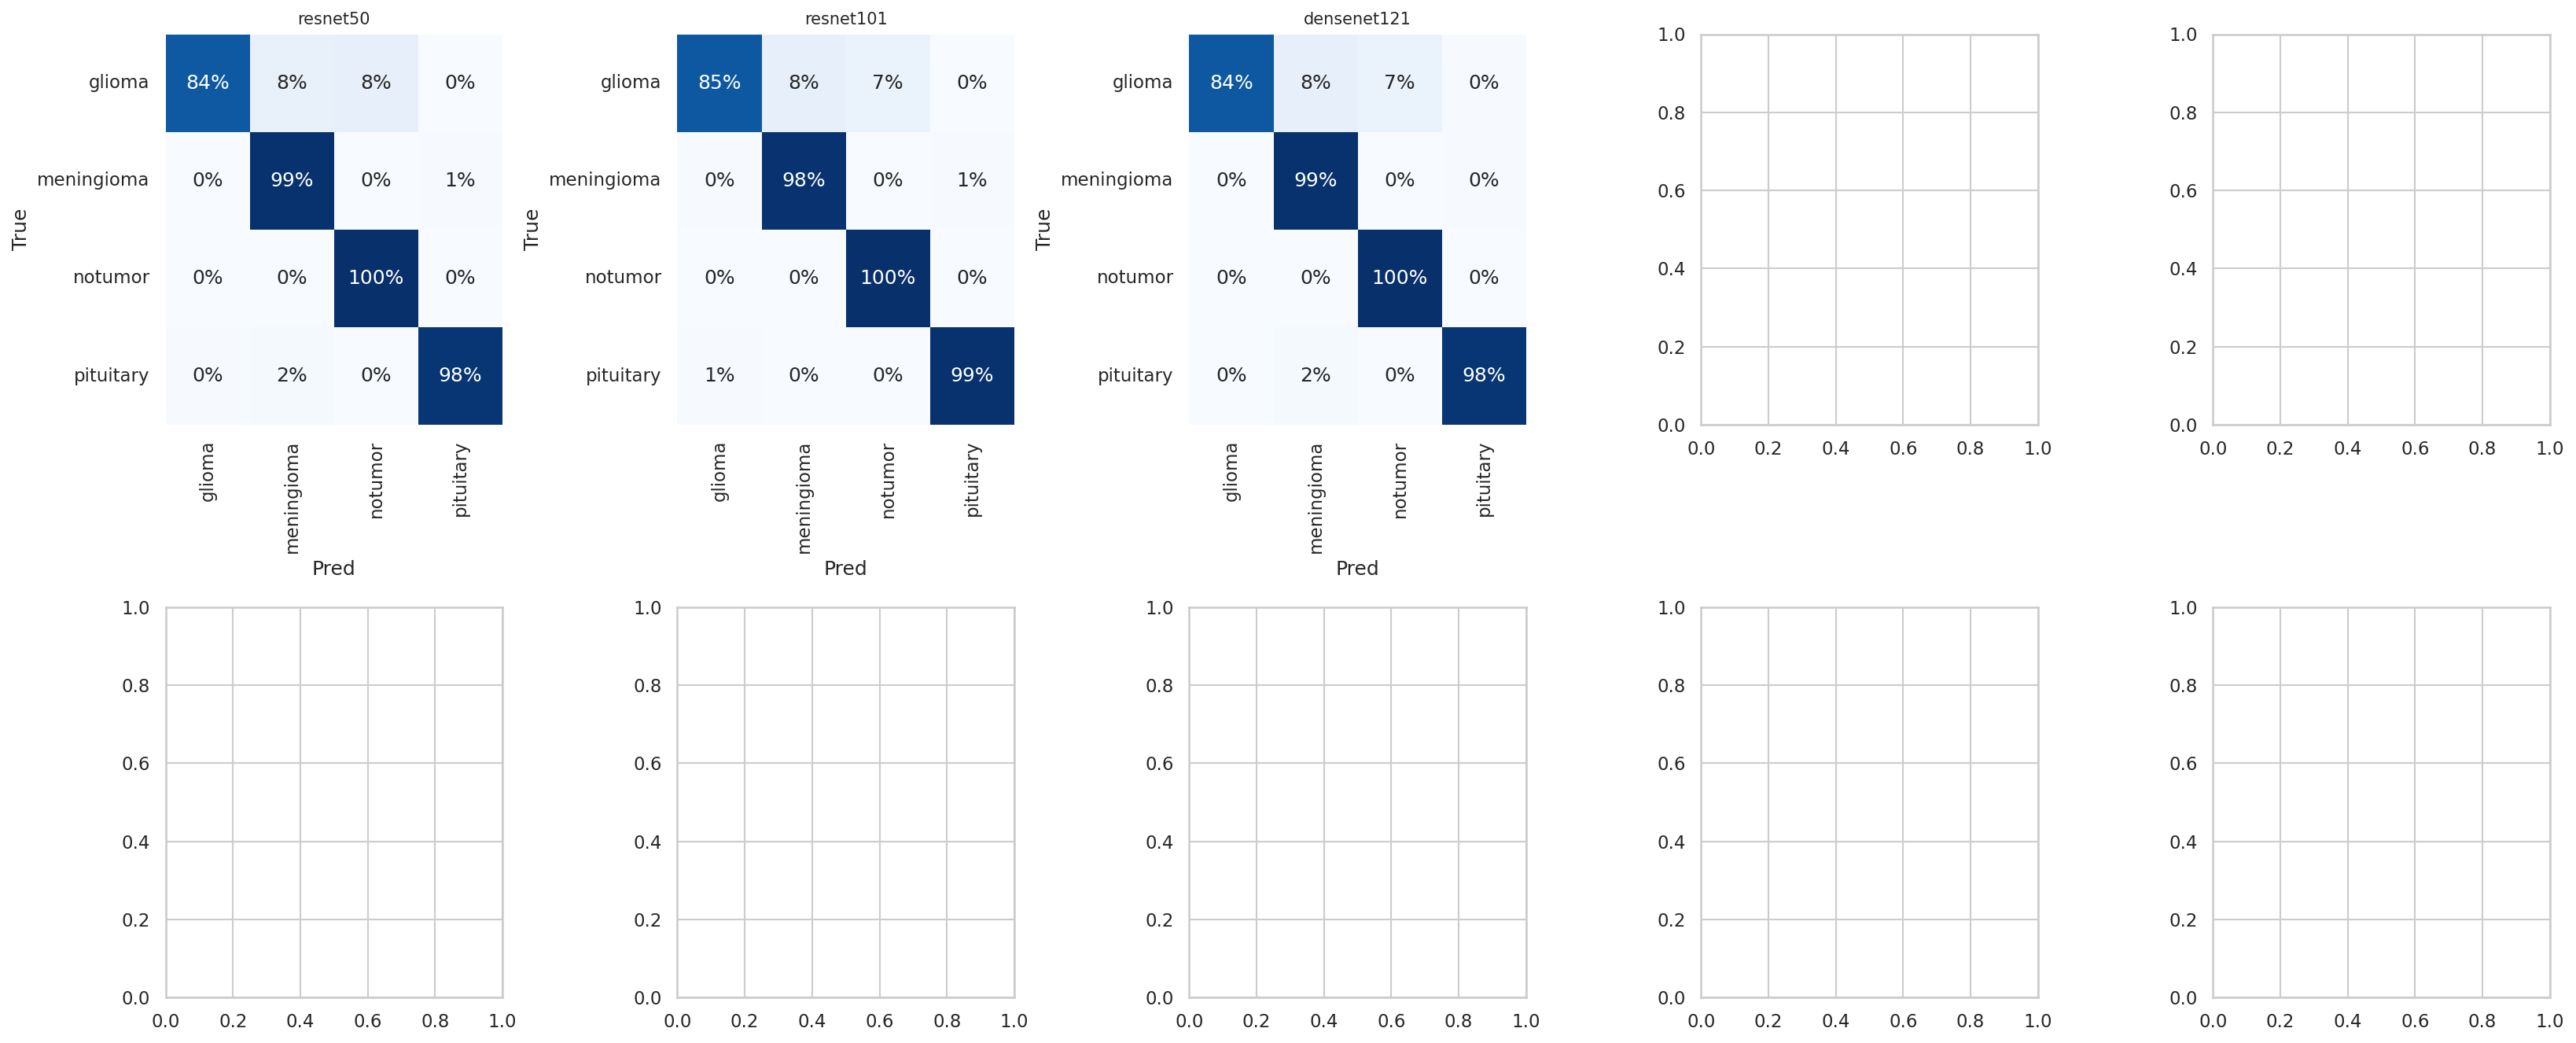

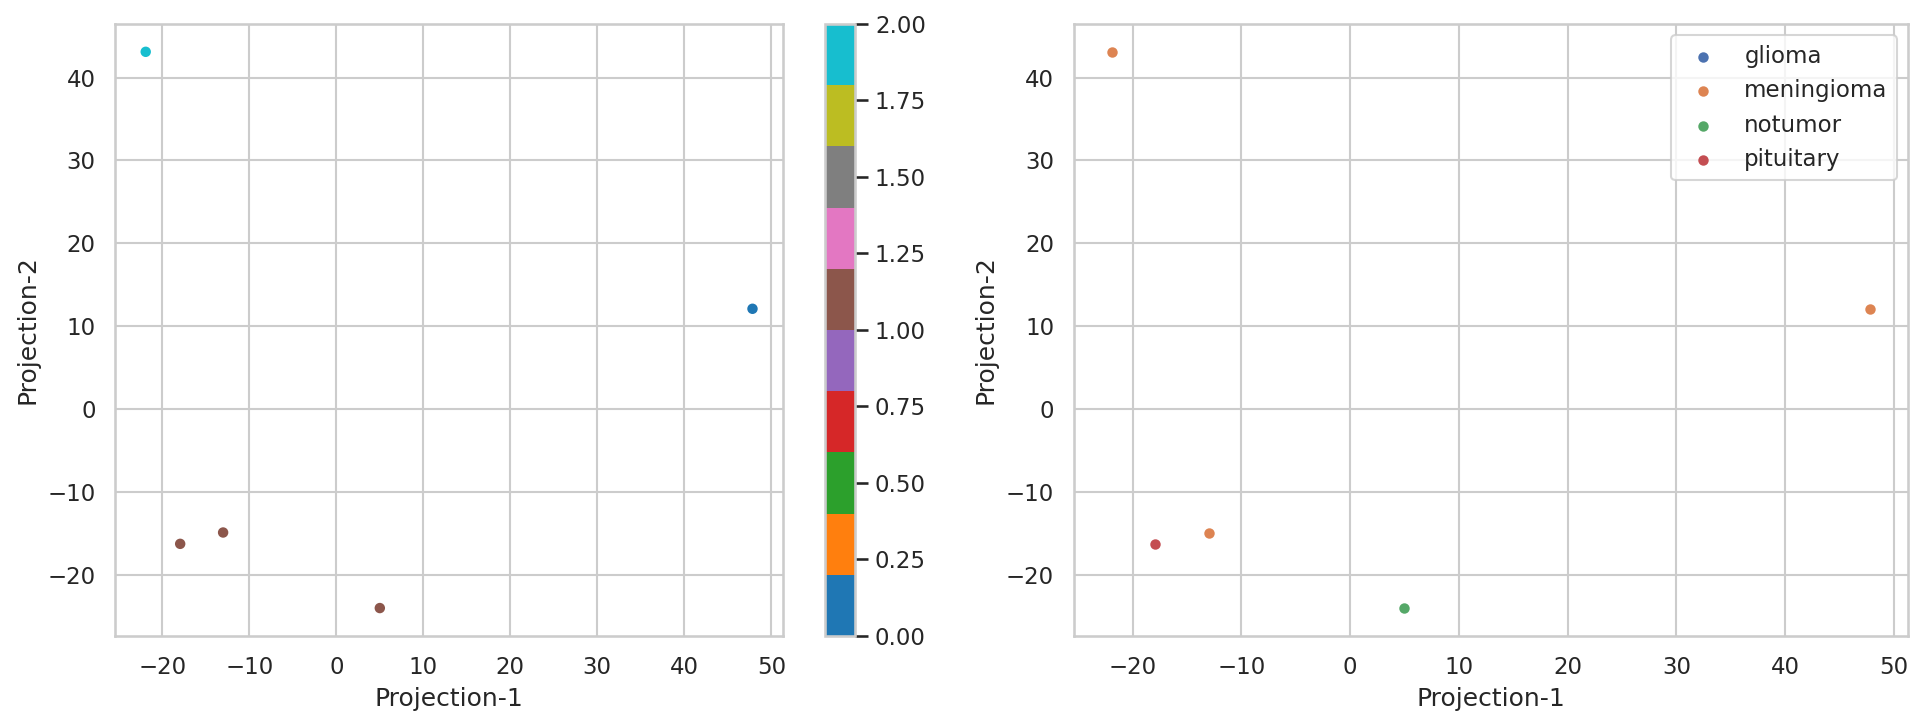

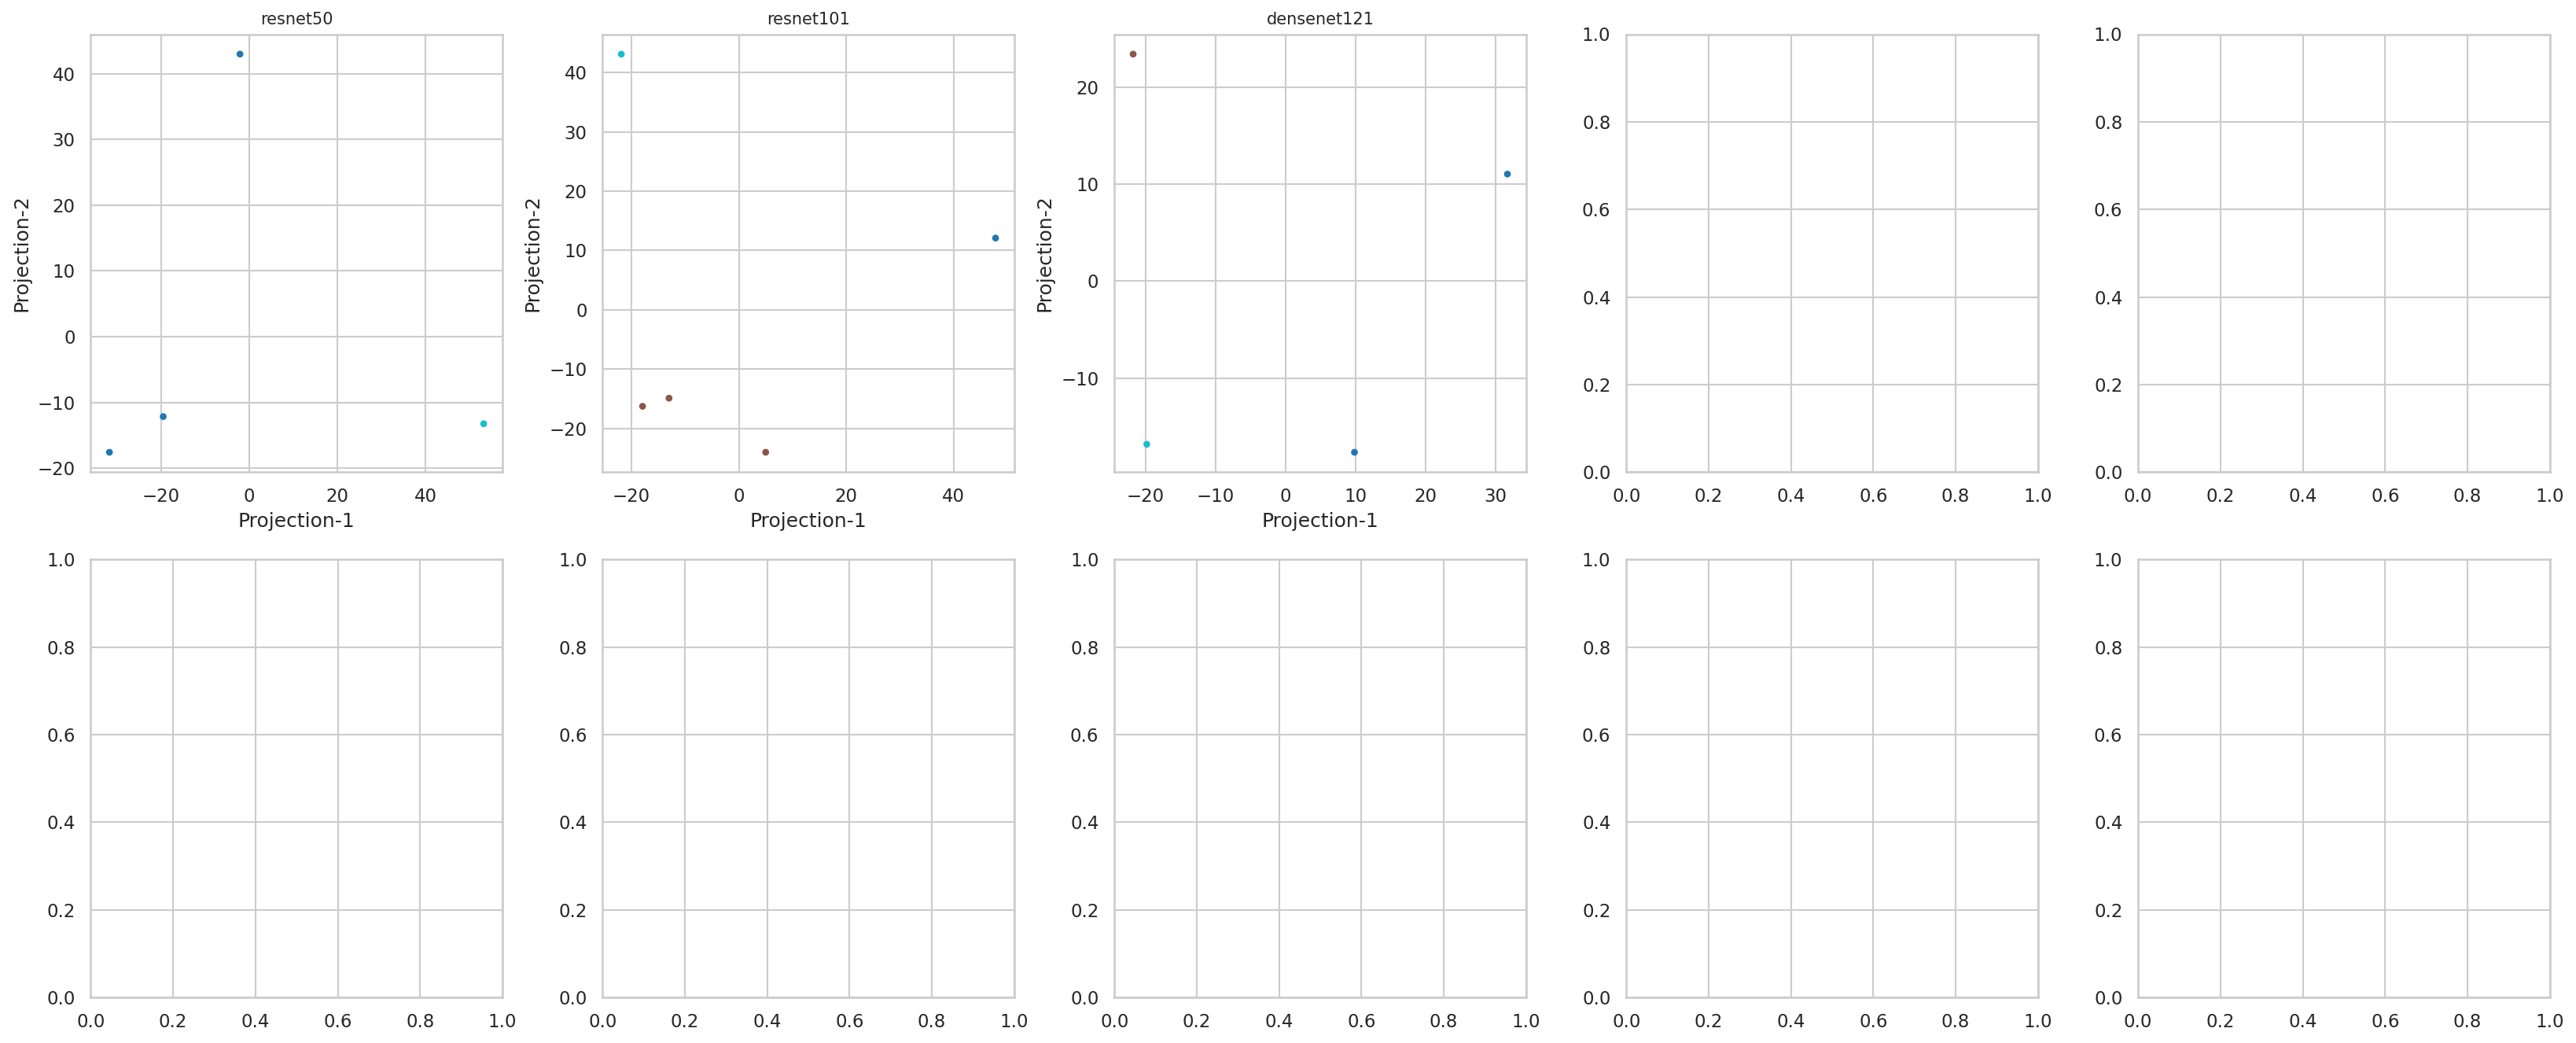

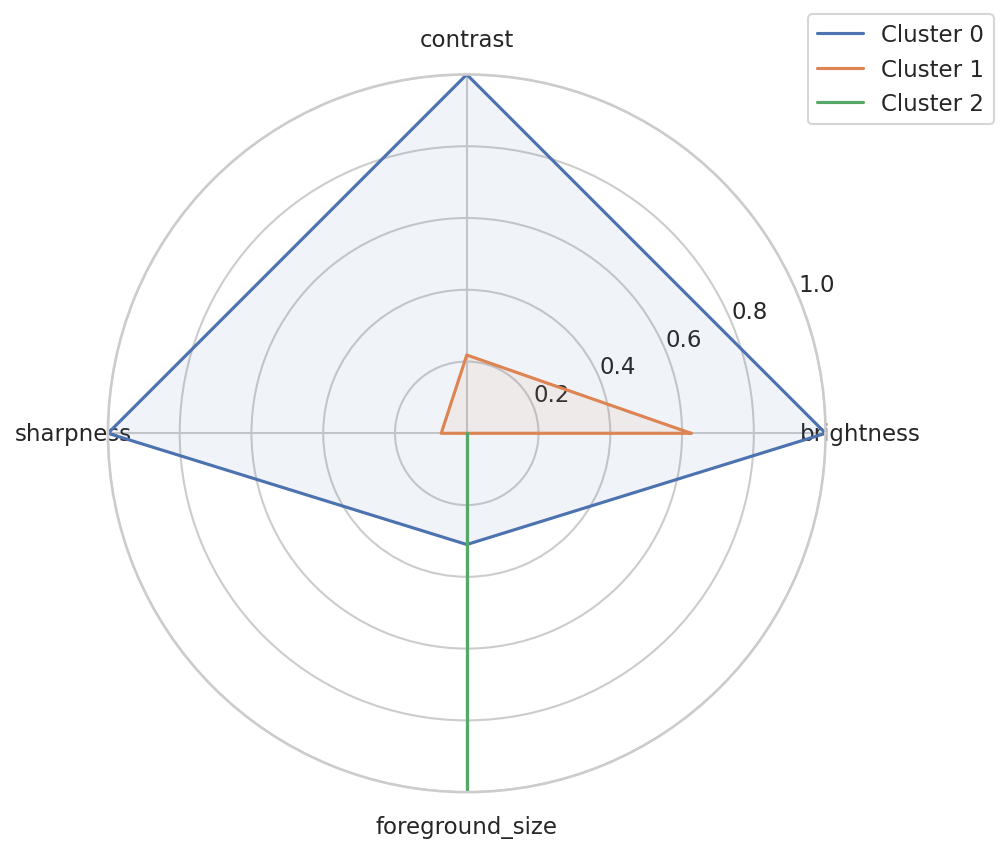

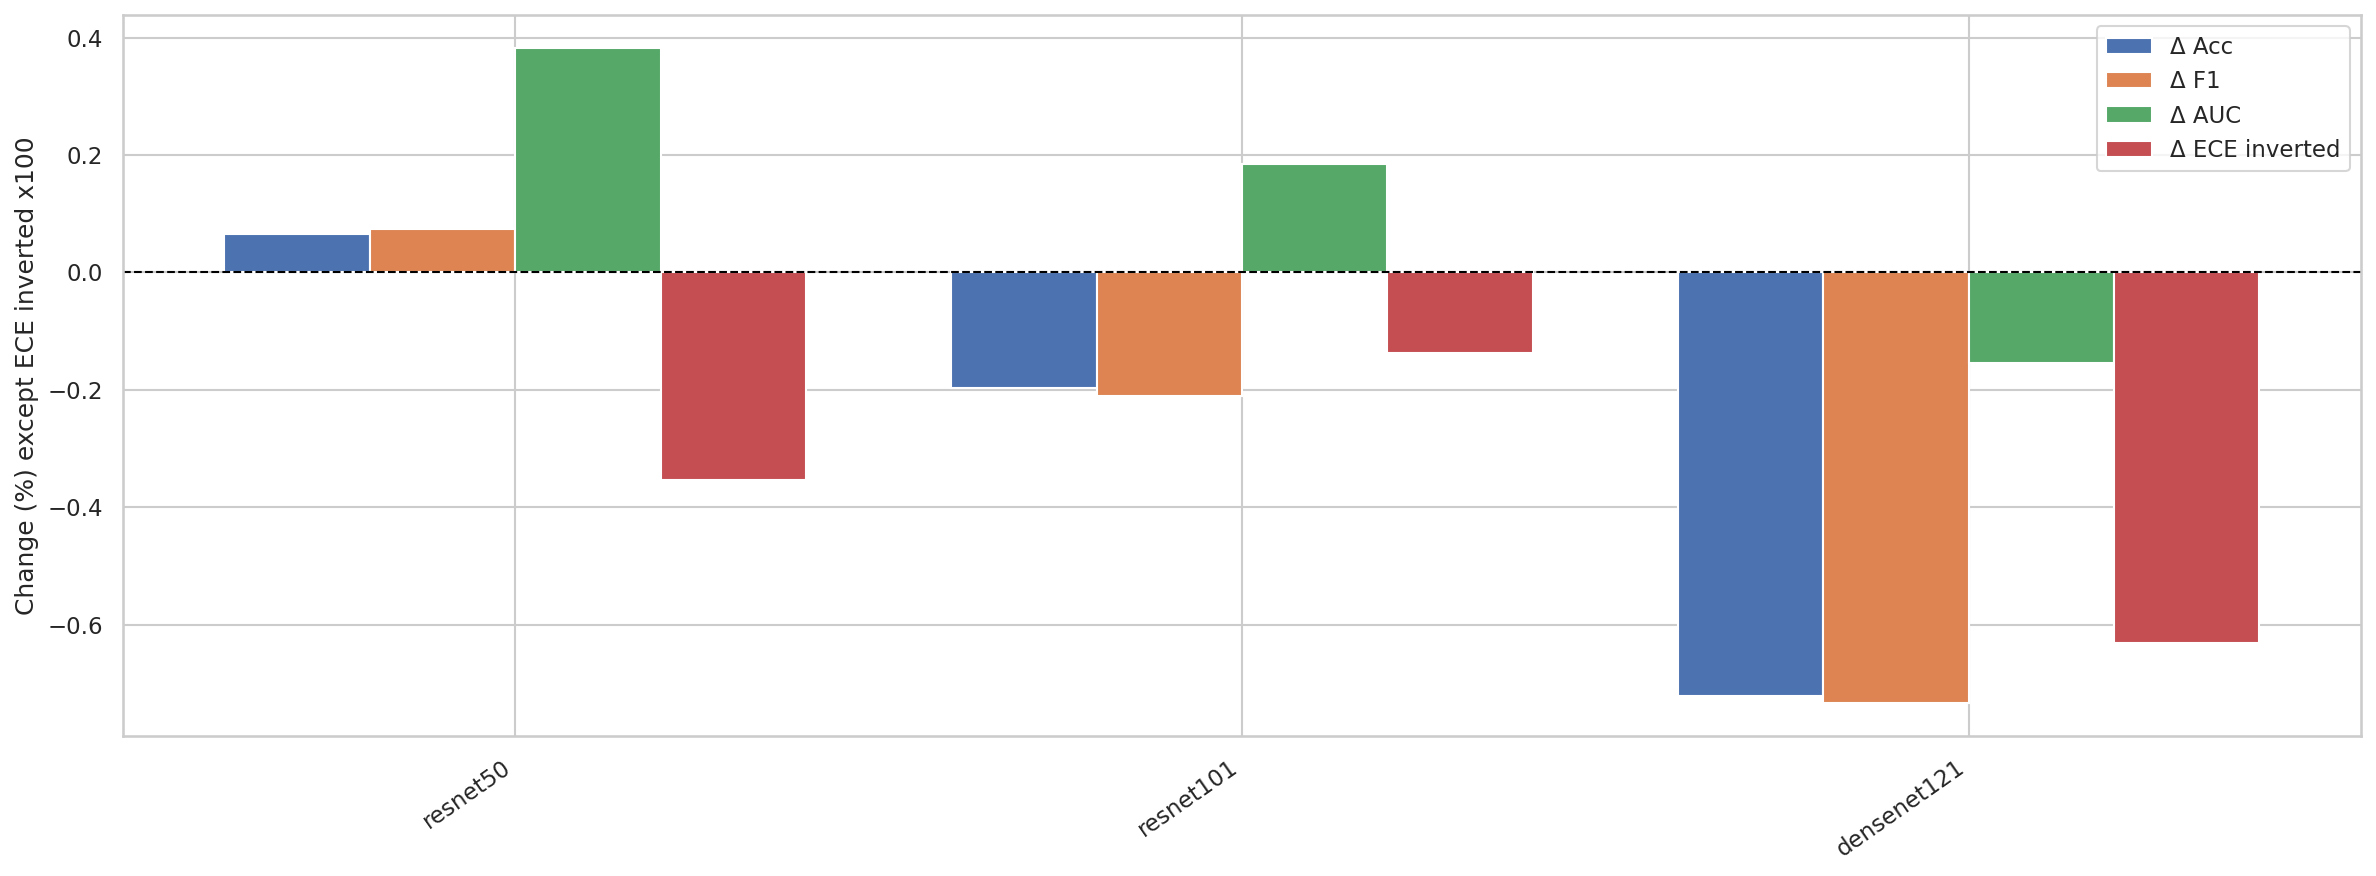

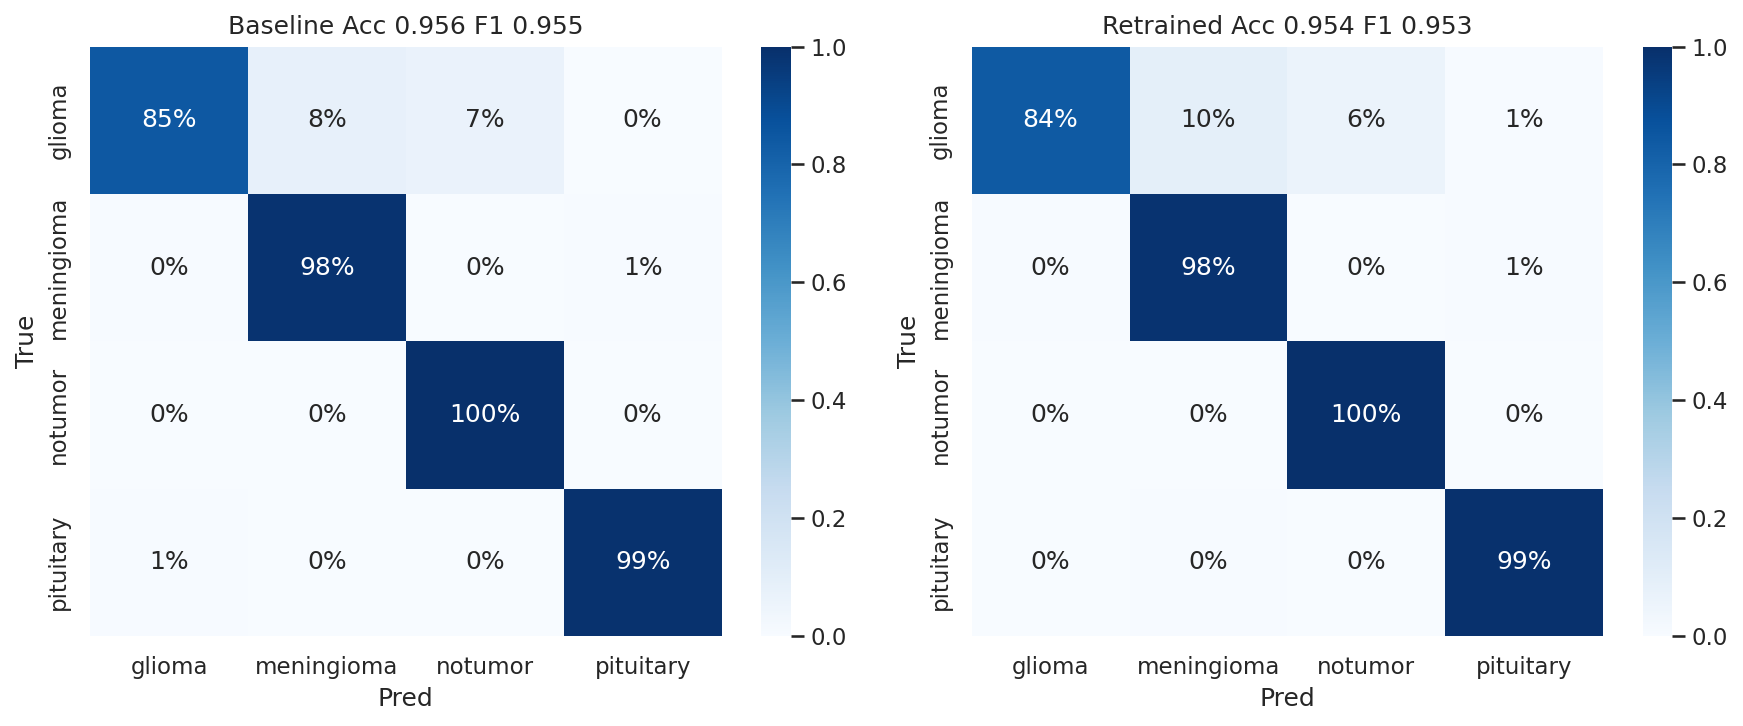

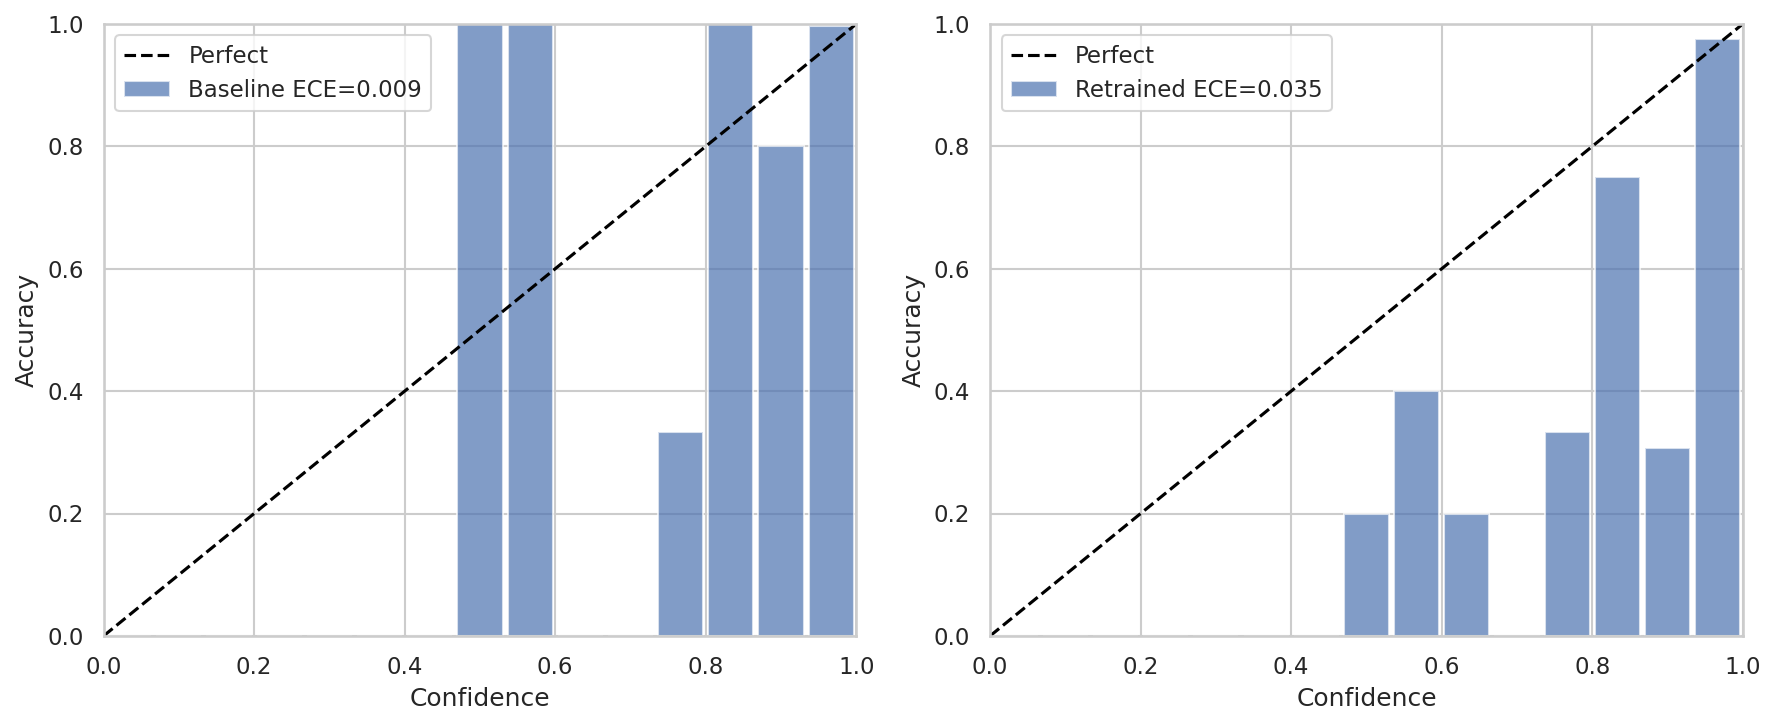

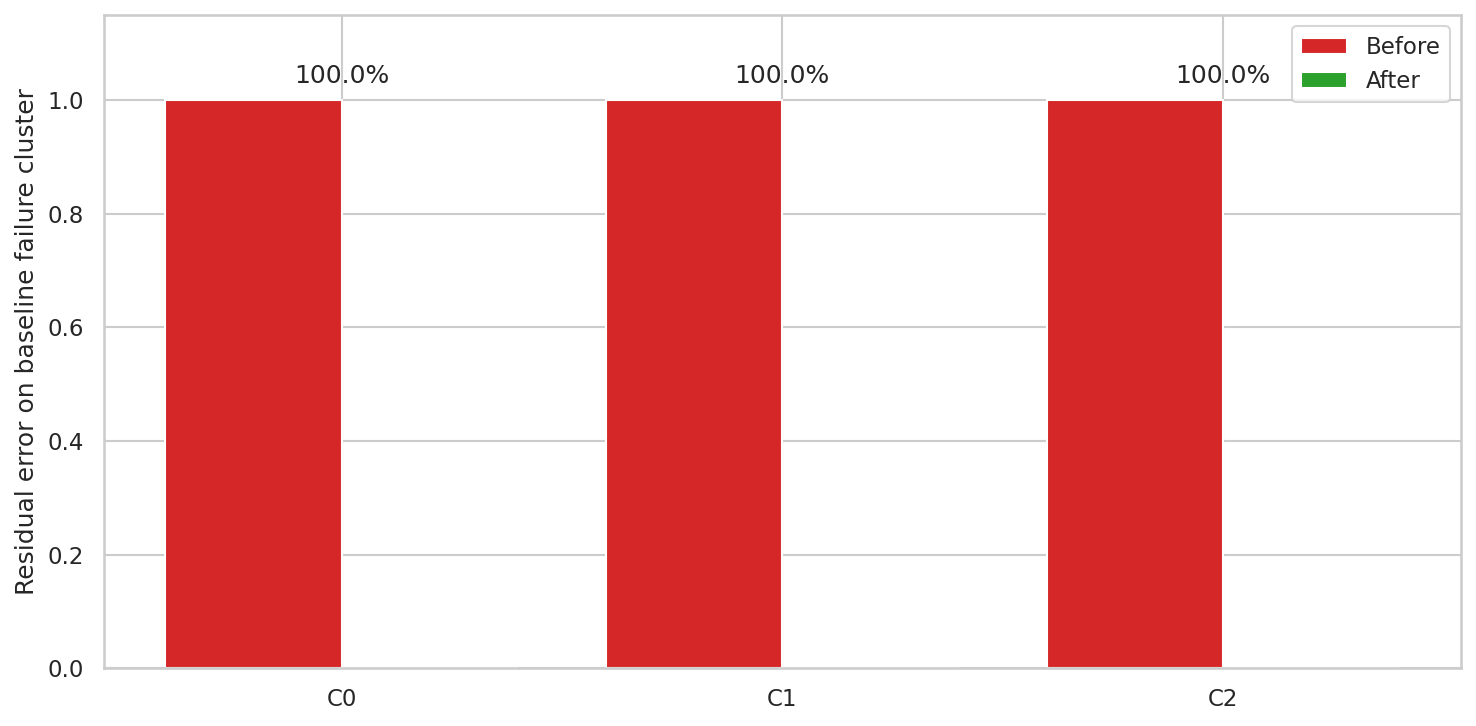

✓ Section 11 complete


In [15]:
def reliability_bins(probs, labels, n_bins=15):
    """Return per-bin confidence and accuracy for reliability diagrams."""
    conf = probs.max(axis=1)
    pred = probs.argmax(axis=1)
    acc = (pred == labels).astype(float)

    bins = np.linspace(0, 1, n_bins + 1)
    centers, bin_acc, bin_conf, counts = [], [], [], []

    for lo, hi in zip(bins[:-1], bins[1:]):
        mask = (conf > lo) & (conf <= hi)
        centers.append((lo + hi) / 2)
        counts.append(mask.sum())
        bin_acc.append(acc[mask].mean() if mask.any() else 0)
        bin_conf.append(conf[mask].mean() if mask.any() else 0)

    return np.array(centers), np.array(bin_acc), np.array(bin_conf), np.array(counts)


if len(improvement_df) > 0:
    best_model = improvement_df.sort_values('retrained_f1', ascending=False).iloc[0]['model']
else:
    best_model = baseline_df.sort_values('test_f1', ascending=False).iloc[0]['model']

print(f"Best model selected for detailed figures: {best_model}")


# Figure 1 — Baseline performance heatmap
fig1_df = baseline_df.set_index('model')[
    ['test_accuracy', 'test_f1', 'test_auc', 'test_ece']
].rename(
    columns={
        'test_accuracy': 'Accuracy',
        'test_f1': 'F1',
        'test_auc': 'AUC',
        'test_ece': 'ECE'
    }
)

plot_df = fig1_df.copy()
plot_df['ECE'] = 1 - plot_df['ECE']

plt.figure(figsize=(8, 6), dpi=150)
sns.heatmap(
    plot_df,
    annot=fig1_df,
    fmt='.3f',
    cmap='RdYlGn',
    cbar=True
)
plt.tight_layout()
plt.savefig(
    f"{CONFIG['figures_dir']}/fig1_baseline_heatmap.png",
    dpi=300,
    bbox_inches='tight'
)
plt.show()


# Figure 2 — Training curves
fig, axes = plt.subplots(2, 5, figsize=(22, 8), dpi=150)

for ax, model_name in zip(axes.ravel(), MODELS):
    hist = all_histories.get(model_name, {})

    if len(hist.get('val_loss', [])) == 0:
        ax.axis('off')
        continue

    epochs = np.arange(1, len(hist['val_loss']) + 1)

    ax.plot(epochs, hist['val_loss'], color='tab:blue')
    ax.set_ylabel('Val loss', color='tab:blue')
    ax.tick_params(axis='y', labelcolor='tab:blue')
    ax.set_xlabel('Epoch')
    ax.set_title(model_name, fontsize=10)

    ax2 = ax.twinx()
    ax2.plot(epochs, hist['val_f1'], color='tab:orange')
    ax2.set_ylabel('Val F1', color='tab:orange')
    ax2.tick_params(axis='y', labelcolor='tab:orange')

plt.tight_layout()
plt.savefig(
    f"{CONFIG['figures_dir']}/fig2_training_curves.png",
    dpi=300,
    bbox_inches='tight'
)
plt.show()


# Figure 3 — Baseline confusion matrices
fig, axes = plt.subplots(2, 5, figsize=(22, 9), dpi=150)

for ax, model_name in zip(axes.ravel(), MODELS):
    if model_name not in baseline_confusions:
        ax.axis('off')
        continue

    cm = baseline_confusions[model_name]
    cmn = np.divide(
        cm,
        cm.sum(axis=1, keepdims=True),
        out=np.zeros_like(cm, dtype=float),
        where=cm.sum(axis=1, keepdims=True) != 0
    )

    sns.heatmap(
        cmn,
        annot=True,
        fmt='.0%',
        cmap='Blues',
        xticklabels=CONFIG['class_names'],
        yticklabels=CONFIG['class_names'],
        ax=ax,
        cbar=False
    )
    ax.set_title(model_name, fontsize=10)
    ax.set_xlabel('Pred')
    ax.set_ylabel('True')

plt.tight_layout()
plt.savefig(
    f"{CONFIG['figures_dir']}/fig3_confusion_baseline.png",
    dpi=300,
    bbox_inches='tight'
)
plt.show()


# Figure 4 — Projection plots for best model
best_clustered = all_clustered[best_model]

fig, axes = plt.subplots(1, 2, figsize=(13, 5), dpi=150)

sc = axes[0].scatter(
    best_clustered['umap_x'],
    best_clustered['umap_y'],
    c=best_clustered['cluster'],
    cmap='tab10',
    s=16
)
axes[0].set_xlabel('Projection-1')
axes[0].set_ylabel('Projection-2')
fig.colorbar(sc, ax=axes[0])

for label_id, name in enumerate(CONFIG['class_names']):
    sub = best_clustered[best_clustered['true_label'] == label_id]
    axes[1].scatter(
        sub['umap_x'],
        sub['umap_y'],
        s=16,
        label=name
    )

axes[1].set_xlabel('Projection-1')
axes[1].set_ylabel('Projection-2')
axes[1].legend()

plt.tight_layout()
plt.savefig(
    f"{CONFIG['figures_dir']}/fig4_projection_best_model.png",
    dpi=300,
    bbox_inches='tight'
)
plt.show()


# Figure 5 — Projection plots for all models
fig, axes = plt.subplots(2, 5, figsize=(22, 9), dpi=150)

for ax, model_name in zip(axes.ravel(), MODELS):
    if model_name not in all_clustered:
        ax.axis('off')
        continue

    cdf = all_clustered[model_name]

    ax.scatter(
        cdf['umap_x'],
        cdf['umap_y'],
        c=cdf['cluster'],
        cmap='tab10',
        s=10
    )
    ax.set_title(model_name, fontsize=10)
    ax.set_xlabel('Projection-1')
    ax.set_ylabel('Projection-2')

plt.tight_layout()
plt.savefig(
    f"{CONFIG['figures_dir']}/fig5_projection_all_models.png",
    dpi=300,
    bbox_inches='tight'
)
plt.show()


# Figure 6 — Cluster profile radar chart
profile_df = all_profiles[best_model]

if len(profile_df) > 0:
    feats = [
        'brightness_mean',
        'contrast_mean',
        'sharpness_mean',
        'foreground_size_mean'
    ]

    radar = profile_df[['cluster'] + feats].copy()

    for feat in feats:
        mn, mx = radar[feat].min(), radar[feat].max()

        if pd.isna(mn) or pd.isna(mx) or mx == mn:
            radar[feat] = 0.5
        else:
            radar[feat] = (radar[feat] - mn) / (mx - mn)

    angles = np.linspace(0, 2 * np.pi, len(feats), endpoint=False).tolist()
    angles += angles[:1]

    fig = plt.figure(figsize=(7, 7), dpi=150)
    ax = fig.add_subplot(111, polar=True)

    for _, row in radar.iterrows():
        values = [row[f] for f in feats]
        values += values[:1]

        ax.plot(
            angles,
            values,
            label=f"Cluster {int(row['cluster'])}"
        )
        ax.fill(angles, values, alpha=0.08)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(['brightness', 'contrast', 'sharpness', 'foreground_size'])
    ax.set_ylim(0, 1)
    ax.legend(loc='upper right', bbox_to_anchor=(1.25, 1.1))

    plt.tight_layout()
    plt.savefig(
        f"{CONFIG['figures_dir']}/fig6_cluster_radar.png",
        dpi=300,
        bbox_inches='tight'
    )
    plt.show()
else:
    print(f"Skipping Figure 6: no cluster profile rows for {best_model}")


# Figure 7 — Improvement bar chart
if len(improvement_df) > 0:
    x = np.arange(len(improvement_df))
    width = 0.2

    fig, ax = plt.subplots(figsize=(16, 6), dpi=150)

    metrics = [
        ('delta_acc_pct', 'Δ Acc'),
        ('delta_f1_pct', 'Δ F1'),
        ('delta_auc_pct', 'Δ AUC'),
        ('delta_ece', 'Δ ECE inverted')
    ]

    for i, (col, label) in enumerate(metrics):
        vals = (
            -100 * improvement_df[col].values
            if col == 'delta_ece'
            else improvement_df[col].values
        )

        ax.bar(
            x + (i - 1.5) * width,
            vals,
            width,
            label=label
        )

    ax.axhline(0, color='black', linestyle='--', linewidth=1)
    ax.set_xticks(x)
    ax.set_xticklabels(improvement_df['model'], rotation=35, ha='right')
    ax.set_ylabel('Change (%) except ECE inverted x100')
    ax.legend()

    plt.tight_layout()
    plt.savefig(
        f"{CONFIG['figures_dir']}/fig7_improvement_bars.png",
        dpi=300,
        bbox_inches='tight'
    )
    plt.show()
else:
    print("Skipping Figure 7: improvement_df is empty")


# Figure 8 — Before vs after confusion matrices
if len(improvement_df) > 0 and best_model in retrained_confusions:
    fig, axes = plt.subplots(1, 2, figsize=(12, 5), dpi=150)

    base_row = baseline_df[baseline_df['model'] == best_model].iloc[0]
    ret_row = improvement_df[improvement_df['model'] == best_model].iloc[0]

    plot_items = [
        (
            axes[0],
            baseline_confusions[best_model],
            f"Baseline Acc {base_row['test_accuracy']:.3f} F1 {base_row['test_f1']:.3f}"
        ),
        (
            axes[1],
            retrained_confusions[best_model],
            f"Retrained Acc {ret_row['retrained_acc']:.3f} F1 {ret_row['retrained_f1']:.3f}"
        )
    ]

    for ax, cm, label in plot_items:
        cmn = np.divide(
            cm,
            cm.sum(axis=1, keepdims=True),
            out=np.zeros_like(cm, dtype=float),
            where=cm.sum(axis=1, keepdims=True) != 0
        )

        sns.heatmap(
            cmn,
            annot=True,
            fmt='.0%',
            cmap='Blues',
            xticklabels=CONFIG['class_names'],
            yticklabels=CONFIG['class_names'],
            ax=ax,
            vmin=0,
            vmax=1
        )

        ax.set_title(label)
        ax.set_xlabel('Pred')
        ax.set_ylabel('True')

    plt.tight_layout()
    plt.savefig(
        f"{CONFIG['figures_dir']}/fig8_confusion_comparison.png",
        dpi=300,
        bbox_inches='tight'
    )
    plt.show()
else:
    print("Skipping Figure 8: retrained results unavailable")


# Figure 9 — Reliability diagrams
if len(improvement_df) > 0 and best_model in retrained_predictions:
    base_pred = all_predictions[best_model]
    base_probs = np.stack(
        base_pred['prob_vector'].apply(lambda x: np.fromstring(x, sep=','))
    )
    base_labels = base_pred['true_label'].values

    ret_probs = retrained_predictions[best_model]['probs']
    ret_labels = retrained_predictions[best_model]['labels']

    fig, axes = plt.subplots(1, 2, figsize=(12, 5), dpi=150)

    plot_items = [
        (
            axes[0],
            base_probs,
            base_labels,
            f"Baseline ECE={compute_ece(base_probs, base_labels):.3f}"
        ),
        (
            axes[1],
            ret_probs,
            ret_labels,
            f"Retrained ECE={compute_ece(ret_probs, ret_labels):.3f}"
        )
    ]

    for ax, probs, labels, caption in plot_items:
        centers, bacc, bconf, counts = reliability_bins(
            probs,
            labels,
            CONFIG['ece_bins']
        )

        ax.bar(
            centers,
            bacc,
            width=1 / CONFIG['ece_bins'] * 0.9,
            alpha=0.7,
            label=caption
        )

        ax.plot(
            [0, 1],
            [0, 1],
            linestyle='--',
            color='black',
            label='Perfect'
        )

        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        ax.set_xlabel('Confidence')
        ax.set_ylabel('Accuracy')
        ax.legend()

    plt.tight_layout()
    plt.savefig(
        f"{CONFIG['figures_dir']}/fig9_ece_reliability.png",
        dpi=300,
        bbox_inches='tight'
    )
    plt.show()
else:
    print("Skipping Figure 9: retrained probability outputs unavailable")


# Figure 10 — Cluster residual error reduction
if len(improvement_df) > 0 and best_model in retrained_predictions:
    clustered = all_clustered[best_model]

    ret_df = pd.DataFrame({
        'image_path': retrained_predictions[best_model]['paths'],
        'true_label': retrained_predictions[best_model]['labels'],
        'pred_label': retrained_predictions[best_model]['preds'],
    })

    cluster_map = clustered[['image_path', 'cluster']].drop_duplicates()
    ret_clustered = ret_df.merge(cluster_map, on='image_path', how='inner')

    before_rates, after_rates = [], []
    clusters = sorted(clustered['cluster'].unique())

    for c in clusters:
        before_rates.append(1.0)

        sub = ret_clustered[ret_clustered['cluster'] == c]

        after_rates.append(
            float((sub['true_label'] != sub['pred_label']).mean())
            if len(sub)
            else 0
        )

    x = np.arange(len(clusters))

    fig, ax = plt.subplots(figsize=(10, 5), dpi=150)

    ax.bar(
        x - 0.2,
        before_rates,
        0.4,
        color='tab:red',
        label='Before'
    )

    ax.bar(
        x + 0.2,
        after_rates,
        0.4,
        color='tab:green',
        label='After'
    )

    for i, (b, a) in enumerate(zip(before_rates, after_rates)):
        ax.text(
            i,
            max(b, a) + 0.03,
            f"{(b - a) * 100:.1f}%",
            ha='center'
        )

    ax.set_xticks(x)
    ax.set_xticklabels([f"C{c}" for c in clusters])
    ax.set_ylabel('Residual error on baseline failure cluster')
    ax.set_ylim(0, 1.15)
    ax.legend()

    plt.tight_layout()
    plt.savefig(
        f"{CONFIG['figures_dir']}/fig10_cluster_error_reduction.png",
        dpi=300,
        bbox_inches='tight'
    )
    plt.show()
else:
    print("Skipping Figure 10: retrained predictions unavailable")

print("✓ Section 11 complete")


In [16]:
def pretty_model_name(name: str) -> str:
    """Convert internal model id to display name."""
    return {
        'resnet50': 'ResNet-50',
        'resnet101': 'ResNet-101',
        'densenet121': 'DenseNet-121',
        'efficientnet_b3': 'EfficientNet-B3',
        'efficientnet_b5': 'EfficientNet-B5',
        'mobilenetv3_large_100': 'MobileNetV3-Large',
        'vit_base_patch16_224': 'ViT-B/16',
        'swin_tiny_patch4_window7_224': 'Swin-Tiny',
        'convnext_small': 'ConvNeXt-Small',
        'maxvit_tiny_tf_224': 'MaxViT-Tiny'
    }.get(name, name)


summary_lines = []

if len(improvement_df) > 0:
    header = (
        "| Model | Family | Acc (base->ret) | F1 (base->ret) | "
        "AUC (base->ret) | ECE (base->ret) | Delta Acc % | Strategy |"
    )
    sep = "|---|---|---:|---:|---:|---:|---:|---|"

    summary_lines.extend([header, sep])

    for _, row in improvement_df.iterrows():
        summary_lines.append(
            f"| {pretty_model_name(row['model'])} | {row['family'].upper()} | "
            f"{row['baseline_acc']:.3f}->{row['retrained_acc']:.3f} | "
            f"{row['baseline_f1']:.3f}->{row['retrained_f1']:.3f} | "
            f"{row['baseline_auc']:.3f}->{row['retrained_auc']:.3f} | "
            f"{row['baseline_ece']:.3f}->{row['retrained_ece']:.3f} | "
            f"{row['delta_acc_pct']:+.1f}% | {row['strategy'].title()} |"
        )
else:
    summary_lines.append(
        "Retraining results are unavailable because `improvement_df` is empty."
    )


best_baseline = None
if len(baseline_df) > 0:
    best_baseline = baseline_df.sort_values(
        'test_f1',
        ascending=False
    ).iloc[0]


most_improved = None
if len(improvement_df) > 0:
    most_improved = improvement_df.sort_values(
        'delta_f1_pct',
        ascending=False
    ).iloc[0]


all_failure_pairs = []

for df in all_failures.values():
    if len(df) == 0:
        continue

    all_failure_pairs.extend(
        list(zip(df['true_label'], df['pred_label']))
    )


if all_failure_pairs:
    dominant = Counter(all_failure_pairs).most_common(1)[0][0]
    dominant_text = (
        f"{CONFIG['class_names'][dominant[0]]} misclassified as "
        f"{CONFIG['class_names'][dominant[1]]}"
    )
else:
    dominant_text = "No dominant failure pattern detected"


clinical_recommendation = (
    "Use the retrained best-F1 model only as a triage/decision-support system, "
    "not as an autonomous diagnostic device. Deploy with calibration monitoring, "
    "subgroup/failure-cluster audits, radiologist override, and prospective "
    "validation on local hospital data before clinical use."
)


final_text = "\n".join(summary_lines) + "\n\n"

if best_baseline is not None:
    final_text += (
        f"- Best performing baseline model: "
        f"{pretty_model_name(best_baseline['model'])} "
        f"(F1={best_baseline['test_f1']:.3f}, "
        f"AUC={best_baseline['test_auc']:.3f})\n"
    )
else:
    final_text += "- Best performing baseline model: unavailable\n"


if most_improved is not None:
    final_text += (
        f"- Most improved model after retraining: "
        f"{pretty_model_name(most_improved['model'])} "
        f"(Delta F1={most_improved['delta_f1_pct']:+.1f}%)\n"
    )
else:
    final_text += "- Most improved model after retraining: unavailable\n"


final_text += f"- Dataset: Brain Tumor MRI 4-class train/test experiment\n"
final_text += f"- Dataset-level dominant failure pattern: {dominant_text}\n"
final_text += f"- Recommendation for clinical deployment: {clinical_recommendation}\n"


print(final_text)

summary_path = Path(CONFIG['results_dir']) / 'FINAL_SUMMARY_BrainMRI.md'
summary_path.write_text(final_text)

print(f"Saved final summary to: {summary_path}")
print("✓ Section 12 complete")


| Model | Family | Acc (base->ret) | F1 (base->ret) | AUC (base->ret) | ECE (base->ret) | Delta Acc % | Strategy |
|---|---|---:|---:|---:|---:|---:|---|
| ResNet-50 | CNN | 0.952->0.953 | 0.951->0.952 | 0.986->0.990 | 0.036->0.040 | +0.1% | Selective |
| ResNet-101 | CNN | 0.956->0.954 | 0.955->0.953 | 0.991->0.993 | 0.034->0.035 | -0.2% | Selective |
| DenseNet-121 | CNN | 0.954->0.947 | 0.953->0.946 | 0.988->0.987 | 0.036->0.042 | -0.7% | Selective |

- Best performing baseline model: ResNet-101 (F1=0.955, AUC=0.991)
- Most improved model after retraining: ResNet-50 (Delta F1=+0.1%)
- Dataset: Brain Tumor MRI 4-class train/test experiment
- Dataset-level dominant failure pattern: meningioma misclassified as notumor
- Recommendation for clinical deployment: Use the retrained best-F1 model only as a triage/decision-support system, not as an autonomous diagnostic device. Deploy with calibration monitoring, subgroup/failure-cluster audits, radiologist override, and prospective validatio

In [17]:

# FINAL: Save cross-notebook results
DATASET_NAME = 'brainmri'

improvement_df['dataset'] = DATASET_NAME
improvement_df.to_csv(f'{CONFIG["results_dir"]}/improvement_{DATASET_NAME}.csv', index=False)

untargeted_df['dataset'] = DATASET_NAME
untargeted_df.to_csv(f'{CONFIG["results_dir"]}/untargeted_control_{DATASET_NAME}.csv', index=False)

cluster_rows = []
for mn, summary in cluster_summaries.items():
    cluster_rows.append({
        'model': mn,
        'dataset': DATASET_NAME,
        'best_k': summary.get('best_k', 2),
        'best_k_bic': summary.get('best_k_bic', 2),
        'silhouette': summary.get('silhouette', float('nan')),
        'mean_ari': summary.get('mean_ari', float('nan')),
        'n_failures': len(all_failures.get(mn, [])),
    })
cluster_summary_df = pd.DataFrame(cluster_rows)
cluster_summary_df.to_csv(f'{CONFIG["results_dir"]}/cluster_summary_{DATASET_NAME}.csv', index=False)

if 'temperature' in baseline_df.columns:
    baseline_df[['model', 'temperature', 'test_ece', 'test_ece_temp_scaled']].to_csv(
        f'{CONFIG["results_dir"]}/temperature_scaling_{DATASET_NAME}.csv', index=False
    )

print(f"Cross-notebook results saved for {DATASET_NAME}")
print(f"  improvement     : {len(improvement_df)} rows")
print(f"  untargeted ctrl : {len(untargeted_df)} rows")
print(f"  cluster summary : {len(cluster_summary_df)} rows")


Cross-notebook results saved for brainmri
  improvement     : 3 rows
  untargeted ctrl : 3 rows
  cluster summary : 3 rows
